In [2]:

import numpy as np
import pandas as pd
import open3d as o3d
from plyfile import PlyData
from sklearn.neighbors import KDTree
from sklearn.decomposition import PCA
from scipy.spatial import cKDTree
import os
import glob
import matplotlib.pyplot as plt
from google.colab import files
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')


data_path = '/content/drive/MyDrive/01/'

Mounted at /content/drive


In [3]:
# 1. ФУНКЦИЯ ЗАГРУЗКИ (рабочая версия)
def read_ply_pointcloud_with_labels(filepath):
    """
    Загружает PLY файл с полем 'scalar_Label'

    Args:
        filepath (str): путь к PLY файлу

    Returns:
        points (np.ndarray): массив координат (N, 3)
        labels (np.ndarray): массив меток (N,)
    """
    with open(filepath, 'rb') as f:
        plydata = PlyData.read(f)

    # Координаты
    x = plydata['vertex']['x']
    y = plydata['vertex']['y']
    z = plydata['vertex']['z']
    points = np.stack([x, y, z], axis=1).astype(np.float32)

    # Метки - используем правильное имя поля
    if 'scalar_Label' in plydata['vertex'].data.dtype.names:
        labels = plydata['vertex']['scalar_Label'].astype(np.int64)
    elif 'scalar_label' in plydata['vertex'].data.dtype.names:
        labels = plydata['vertex']['scalar_label'].astype(np.int64)
    else:
        label_fields = ['scalar_Label', 'scalar_label', 'label', 'class', 'Label']
        found = False
        for field in label_fields:
            if field in plydata['vertex'].data.dtype.names:
                labels = plydata['vertex'][field].astype(np.int64)
                found = True
                break
        if not found:
            raise ValueError(f"Не найдено поле с метками. Доступные поля: {plydata['vertex'].data.dtype.names}")

    return points, labels

# 2. ФУНКЦИЯ ПРЕДОБРАБОТКИ
def preprocess_pointcloud(points, labels=None, remove_outliers=True,
                          nb_neighbors=20, std_ratio=2.0,
                          normalize=True):
    """
    Предобработка облака точек:
    1. Удаление статистических выбросов (опционально)
    2. Центрирование координат

    Args:
        points (np.ndarray): массив координат (N, 3)
        labels (np.ndarray): массив меток (N,) - опционально
        remove_outliers (bool): удалять ли выбросы
        nb_neighbors (int): количество соседей для фильтрации
        std_ratio (float): порог std для фильтрации
        normalize (bool): центрировать ли координаты

    Returns:
        points_clean (np.ndarray): очищенные координаты
        labels_clean (np.ndarray): очищенные метки (если были переданы)
    """
    if points.shape[0] < 10:
        return points, labels if labels is not None else points

    # Создаем open3d облако для использования встроенной фильтрации
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    # Статистическая фильтрация выбросов
    if remove_outliers and points.shape[0] > 50:
        cl, ind = pcd.remove_statistical_outlier(
            nb_neighbors=nb_neighbors,
            std_ratio=std_ratio
        )

        if len(ind) > 0 and len(ind) > points.shape[0] * 0.1:  # Не удаляем более 90%
            clean_pts = np.asarray(cl.points)
            if labels is not None:
                clean_labels = labels[ind]
            else:
                clean_labels = None
        else:
            clean_pts = points.copy()
            clean_labels = labels.copy() if labels is not None else None
    else:
        clean_pts = points.copy()
        clean_labels = labels.copy() if labels is not None else None

    # Центрирование координат (вычитание среднего)
    if normalize:
        mean_center = np.mean(clean_pts, axis=0)
        clean_pts = clean_pts - mean_center

    if labels is not None:
        return clean_pts, clean_labels
    else:
        return clean_pts

# 3. ФУНКЦИЯ ДЛЯ ИЗВЛЕЧЕНИЯ СЕГМЕНТОВ
def extract_segments(points, labels, min_points=50):
    """
    Извлекает сегменты по меткам

    Args:
        points (np.ndarray): массив координат (N, 3)
        labels (np.ndarray): массив меток (N,)
        min_points (int): минимальное количество точек в сегменте

    Returns:
        dict: {label: points_array}
    """
    unique_labels = np.unique(labels)
    segments = {}

    for label in unique_labels:
        mask = labels == label
        segment_points = points[mask]

        # Пропускаем слишком маленькие сегменты
        if len(segment_points) >= min_points:
            segments[label] = segment_points

    return segments

# 4. ФУНКЦИЯ ДЛЯ АНАЛИЗА СТРУКТУРЫ ДАННЫХ
def analyze_dataset_structure(data_path, num_samples=5):
    """
    Анализирует структуру датасета на основе нескольких файлов

    Args:
        data_path (str): путь к папке с данными
        num_samples (int): количество файлов для анализа

    Returns:
        dict: статистика по датасету
    """
    files = sorted(glob.glob(os.path.join(data_path, '*.ply')))[:num_samples]

    if not files:
        print(f"❌ В папке {data_path} нет PLY файлов")
        return None

    stats = {
        'total_files': len(glob.glob(os.path.join(data_path, '*.ply'))),
        'samples_analyzed': len(files),
        'points_per_file': [],
        'labels_per_file': [],
        'unique_labels_all': [],
        'segment_counts': {}
    }

    print(f"🔍 Анализ {len(files)} файлов из {stats['total_files']}...")

    for filepath in tqdm(files, desc="Анализ"):
        try:
            points, labels = read_ply_pointcloud_with_labels(filepath)

            stats['points_per_file'].append(len(points))
            unique_labels = np.unique(labels)
            stats['labels_per_file'].append(len(unique_labels))
            stats['unique_labels_all'].append(set(unique_labels))

            # Считаем точки по сегментам
            for label in unique_labels:
                count = np.sum(labels == label)
                if label not in stats['segment_counts']:
                    stats['segment_counts'][label] = []
                stats['segment_counts'][label].append(count)

        except Exception as e:
            print(f"⚠️ Ошибка при анализе {filepath}: {e}")

    return stats

In [5]:
# 5. ТЕСТИРОВАНИЕ НА ОДНОМ ФАЙЛЕ

# Укажите путь к вашей папке с данными
# Например: /content/drive/MyDrive/01/
data_path = '/content/drive/MyDrive/01/'  # ИЗМЕНИТЕ НА ВАШ ПУТЬ

# Ищем файлы
files = sorted(glob.glob(os.path.join(data_path, '*.ply')))
print(f"Найдено файлов: {len(files)}")

if files:
    # Берем первый файл для теста
    test_file = files[0]
    print(f"\n📁 Тестовый файл: {os.path.basename(test_file)}")

    # Загружаем
    points, labels = read_ply_pointcloud_with_labels(test_file)

    print(f"\n📊 Исходные данные:")
    print(f"  Количество точек: {len(points):,}")
    print(f"  Форма points: {points.shape}")
    print(f"  Уникальные метки: {np.unique(labels)}")
    print(f"  Количество сегментов: {len(np.unique(labels))}")

    # Статистика по сегментам
    print(f"\n📈 Распределение точек по сегментам:")
    for label in sorted(np.unique(labels)):
        count = np.sum(labels == label)
        percentage = count / len(points) * 100
        print(f"  Label {label}: {count:6,} точек ({percentage:5.1f}%)")

    # Предобработка
    points_clean, labels_clean = preprocess_pointcloud(
        points, labels,
        remove_outliers=True,
        nb_neighbors=20,
        std_ratio=2.0,
        normalize=True
    )

    print(f"\n🔧 После предобработки:")
    print(f"  Количество точек: {len(points_clean):,}")
    print(f"  Удалено точек: {len(points) - len(points_clean):,}")
    print(f"  Уникальные метки: {np.unique(labels_clean)}")
    print(f"  Диапазон X: {points_clean[:, 0].min():.2f} .. {points_clean[:, 0].max():.2f}")
    print(f"  Диапазон Y: {points_clean[:, 1].min():.2f} .. {points_clean[:, 1].max():.2f}")
    print(f"  Диапазон Z: {points_clean[:, 2].min():.2f} .. {points_clean[:, 2].max():.2f}")

    # Извлекаем сегменты
    segments = extract_segments(points_clean, labels_clean, min_points=50)

    print(f"\n📦 Извлечено сегментов: {len(segments)}")
    for label, seg_points in sorted(segments.items()):
        print(f"  Сегмент {label}: {len(seg_points):,} точек")

Найдено файлов: 503

📁 Тестовый файл: valve_0001_lidar_classes.ply

📊 Исходные данные:
  Количество точек: 4,899
  Форма points: (4899, 3)
  Уникальные метки: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
  Количество сегментов: 16

📈 Распределение точек по сегментам:
  Label 0:  1,396 точек ( 28.5%)
  Label 1:     21 точек (  0.4%)
  Label 2:      6 точек (  0.1%)
  Label 3:     48 точек (  1.0%)
  Label 4:     42 точек (  0.9%)
  Label 5:    276 точек (  5.6%)
  Label 6:     92 точек (  1.9%)
  Label 7:    413 точек (  8.4%)
  Label 8:      2 точек (  0.0%)
  Label 9:      1 точек (  0.0%)
  Label 10:  1,136 точек ( 23.2%)
  Label 11:    905 точек ( 18.5%)
  Label 12:     93 точек (  1.9%)
  Label 13:    210 точек (  4.3%)
  Label 14:    222 точек (  4.5%)
  Label 15:     36 точек (  0.7%)

🔧 После предобработки:
  Количество точек: 4,721
  Удалено точек: 178
  Уникальные метки: [ 0  1  2  3  4  5  6  7 10 11 12 13 14 15]
  Диапазон X: -4.84 .. 7.31
  Диапазон Y: -4.14 .. 6.60
  

In [7]:
# 6. АНАЛИЗ ВСЕГО ДАТАСЕТА
print("=" * 60)
print("АНАЛИЗ ВСЕГО ДАТАСЕТА")
print("=" * 60)

dataset_stats = analyze_dataset_structure(data_path, num_samples=10)

if dataset_stats:
    print(f"\n📊 СТАТИСТИКА ДАТАСЕТА:")
    print(f"  Всего файлов: {dataset_stats['total_files']}")
    print(f"  Проанализировано: {dataset_stats['samples_analyzed']}")

    points_arr = np.array(dataset_stats['points_per_file'])
    print(f"\n  Количество точек на файл:")
    print(f"    Среднее: {points_arr.mean():.0f}")
    print(f"    Медиана: {np.median(points_arr):.0f}")
    print(f"    Мин: {points_arr.min()}")
    print(f"    Макс: {points_arr.max()}")

    labels_arr = np.array(dataset_stats['labels_per_file'])
    print(f"\n  Количество сегментов на файл:")
    print(f"    Среднее: {labels_arr.mean():.1f}")
    print(f"    Медиана: {np.median(labels_arr):.0f}")
    print(f"    Мин: {labels_arr.min()}")
    print(f"    Макс: {labels_arr.max()}")

    # Общие метки во всех файлах
    common_labels = set.intersection(*dataset_stats['unique_labels_all']) if dataset_stats['unique_labels_all'] else set()
    print(f"\n  Общие метки во всех файлах: {sorted(common_labels)}")

    # Статистика по сегментам
    print(f"\n  Размеры сегментов (среднее по файлам):")
    for label in sorted(dataset_stats['segment_counts'].keys()):
        counts = dataset_stats['segment_counts'][label]
        if counts:
            print(f"    Label {label}: {np.mean(counts):.0f} ± {np.std(counts):.0f} точек")

АНАЛИЗ ВСЕГО ДАТАСЕТА
🔍 Анализ 10 файлов из 503...


Анализ: 100%|██████████| 10/10 [00:10<00:00,  1.00s/it]


📊 СТАТИСТИКА ДАТАСЕТА:
  Всего файлов: 503
  Проанализировано: 10

  Количество точек на файл:
    Среднее: 5361
    Медиана: 5444
    Мин: 4899
    Макс: 5709

  Количество сегментов на файл:
    Среднее: 15.7
    Медиана: 16
    Мин: 14
    Макс: 16

  Общие метки во всех файлах: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

  Размеры сегментов (среднее по файлам):
    Label 0: 1469 ± 160 точек
    Label 1: 19 ± 9 точек
    Label 2: 24 ± 14 точек
    Label 3: 39 ± 14 точек
    Label 4: 33 ± 18 точек
    Label 5: 245 ± 64 точек
    Label 6: 95 ± 19 точек
    Label 7: 488 ± 52 точек
    Label 8: 11 ± 6 точек
    Label 9: 7 ± 6 точек
    Label 10: 1123 ± 156 точек
    Label 11: 1151 ± 156 точек
    Label 12: 183 ± 54 точек
    Label 13: 172 ± 67 точек
    Label 14: 150 ± 59 точек
    Label 15: 152 ± 74 точек


🔍 Визуализация облака точек с цветовой кодировкой по сегментам


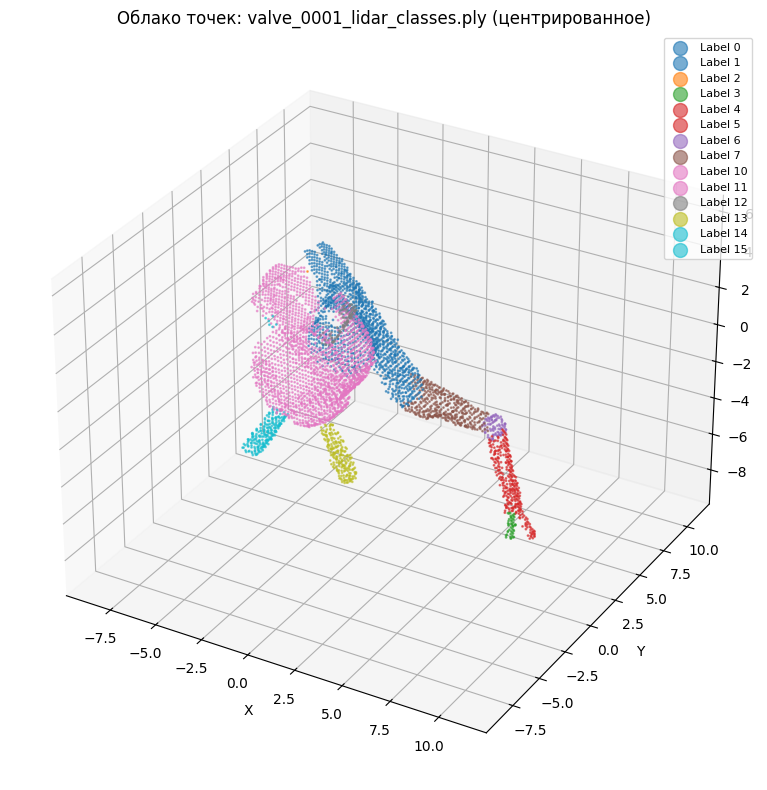

In [6]:
# 7. ВИЗУАЛИЗАЦИЯ ОДНОГО ОБЛАКА
def visualize_pointcloud(points, labels=None, title="Point Cloud"):
    """
    Визуализирует облако точек с цветовой кодировкой по меткам
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    if labels is not None:
        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

        for i, label in enumerate(unique_labels):
            mask = labels == label
            ax.scatter(points[mask, 0], points[mask, 1], points[mask, 2],
                      c=[colors[i]], s=1, alpha=0.6, label=f'Label {label}')
        ax.legend(markerscale=10, loc='upper right', fontsize=8)
    else:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                  c='blue', s=1, alpha=0.6)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.axis('equal')

    plt.tight_layout()
    plt.show()

# Визуализируем загруженное облако
if files:
    print("🔍 Визуализация облака точек с цветовой кодировкой по сегментам")
    visualize_pointcloud(points_clean, labels_clean,
                        title=f"Облако точек: {os.path.basename(test_file)} (центрированное)")

In [7]:

def extract_segments_enhanced(points, labels, min_points=50, max_points=None):
    """
    Извлекает сегменты по меткам с дополнительной валидацией

    Args:
        points (np.ndarray): массив координат (N, 3)
        labels (np.ndarray): массив меток (N,)
        min_points (int): минимальное количество точек в сегменте
        max_points (int): максимальное количество точек (для даунсэмплинга)

    Returns:
        dict: {label: {'points': points_array, 'n_points': int, 'percentage': float}}
    """
    unique_labels = np.unique(labels)
    segments = {}
    total_points = len(points)

    for label in unique_labels:
        mask = labels == label
        segment_points = points[mask]
        n_points = len(segment_points)

        # Пропускаем слишком маленькие сегменты
        if n_points >= min_points:
            # Опциональный даунсэмплинг для больших сегментов
            if max_points is not None and n_points > max_points:
                indices = np.random.choice(n_points, max_points, replace=False)
                segment_points = segment_points[indices]
                n_points = max_points

            segments[label] = {
                'points': segment_points,
                'n_points': n_points,
                'percentage': n_points / total_points * 100
            }

    return segments

# 10. ГЕОМЕТРИЧЕСКИЙ АНАЛИЗ СЕГМЕНТА
def analyze_segment_geometry(pts):
    """
    Выполняет полный геометрический анализ сегмента

    Args:
        pts (np.ndarray): массив координат (N, 3)

    Returns:
        dict: геометрические характеристики
    """
    if len(pts) < 10:
        return {'error': 'Too few points', 'n_points': len(pts)}

    n_points = len(pts)

    # ============================================
    # 6.1 Плотность точек
    # ============================================
    # Строим KDTree
    tree = KDTree(pts)

    # Среднее расстояние до 5 ближайших соседей (k=6, т.к. первая точка - сама себе)
    k = min(6, n_points)
    if k > 1:
        distances, _ = tree.query(pts, k=k)
        mean_nn_distances = np.mean(distances[:, 1:], axis=1)  # исключаем первую (0)
        density_mean = np.mean(mean_nn_distances)
        density_std = np.std(mean_nn_distances)
        density_cv = density_std / density_mean if density_mean > 0 else 0  # коэффициент вариации
    else:
        density_mean = 0
        density_std = 0
        density_cv = 0

    centered = pts - np.mean(pts, axis=0)

    # PCA
    pca = PCA(n_components=3)
    pca.fit(centered)
    eigenvalues = pca.explained_variance_
    eigenvalues_normalized = eigenvalues / np.sum(eigenvalues)

    ev1, ev2, ev3 = eigenvalues_normalized

    # Индексы формы
    linearity = (ev1 - ev2) / ev1 if ev1 > 0 else 0
    planarity = (ev2 - ev3) / ev1 if ev1 > 0 else 0
    sphericity = ev3 / ev1 if ev1 > 0 else 0

    # Определяем форму
    if ev1 > 0.85:
        shape_type = 'linear'
    elif ev1 + ev2 > 0.95:
        shape_type = 'planar'
    elif ev3 / ev1 > 0.5:
        shape_type = 'spherical'
    else:
        shape_type = 'complex'

    sample_size = min(500, n_points)
    if n_points > sample_size:
        sample_indices = np.random.choice(n_points, sample_size, replace=False)
        sample_pts = pts[sample_indices]
    else:
        sample_pts = pts

    curvatures = []
    k_neighbors = min(15, len(sample_pts) - 1)

    if k_neighbors > 2:
        tree_local = KDTree(pts)  # используем все точки для поиска соседей

        for i, point in enumerate(sample_pts):
            # Находим соседей
            distances, indices = tree_local.query([point], k=k_neighbors + 1)
            neighbor_pts = pts[indices[0][1:]]  # исключаем саму точку

            if len(neighbor_pts) >= 3:
                # Локальный PCA
                centered_neighbors = neighbor_pts - np.mean(neighbor_pts, axis=0)
                cov = np.cov(centered_neighbors.T)
                eigvals = np.linalg.eigvalsh(cov)
                eigvals = np.sort(eigvals)[::-1]  # сортируем по убыванию

                # Кривизна = наименьшее собственное значение / сумма
                if np.sum(eigvals) > 0:
                    curvature = eigvals[-1] / np.sum(eigvals)
                    curvatures.append(curvature)

    if curvatures:
        mean_curvature = np.mean(curvatures)
        std_curvature = np.std(curvatures)
        max_curvature = np.max(curvatures)
    else:
        mean_curvature = 0
        std_curvature = 0
        max_curvature = 0

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)

    # Оценка нормалей
    k_normals = min(20, n_points - 1)
    if k_normals > 3:
        pcd.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamKNN(k_normals)
        )
        # Ориентация нормалей
        pcd.orient_normals_consistent_tangent_plane(k=10)
        normals = np.asarray(pcd.normals)

        # Оценка согласованности нормалей
        tree_normals = KDTree(pts)
        consistency_scores = []
        sample_size_normals = min(800, n_points)

        if n_points > sample_size_normals:
            sample_idx = np.random.choice(n_points, sample_size_normals, replace=False)
        else:
            sample_idx = np.arange(n_points)

        for idx in sample_idx:
            # Находим соседей
            distances, indices = tree_normals.query([pts[idx]], k=min(20, n_points))
            neighbor_indices = indices[0][1:]  # исключаем саму точку

            if len(neighbor_indices) > 0:
                # Вычисляем косинусное сходство нормалей
                normal_i = normals[idx]
                similarities = []
                for n_idx in neighbor_indices:
                    similarity = np.abs(np.dot(normal_i, normals[n_idx]))
                    similarities.append(similarity)
                consistency_scores.append(np.mean(similarities))

        if consistency_scores:
            mean_consistency = np.mean(consistency_scores)
            std_consistency = np.std(consistency_scores)
        else:
            mean_consistency = 0
            std_consistency = 0
    else:
        mean_consistency = 0
        std_consistency = 0
        normals = None

    # ============================================
    # 6.5 Топологическая связность (DBSCAN)
    # ============================================
    from sklearn.cluster import DBSCAN

    eps = density_mean * 3.0 if density_mean > 0 else 0.5

    if n_points > 50 and eps > 0:
        dbscan = DBSCAN(eps=eps, min_samples=3)
        cluster_labels = dbscan.fit_predict(pts)

        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = np.sum(cluster_labels == -1)
        noise_ratio = n_noise / n_points

        # Классификация связности
        if n_clusters == 1 and noise_ratio < 0.05:
            connectivity = 'connected'
        elif n_clusters <= 3:
            connectivity = 'few_components'
        else:
            connectivity = 'fragmented'
    else:
        n_clusters = 0
        noise_ratio = 0
        connectivity = 'unknown'
        cluster_labels = None

    # ============================================
    # Сбор всех характеристик
    # ============================================
    result = {
        'n_points': n_points,

        # Плотность
        'density_mean': density_mean,
        'density_std': density_std,
        'density_cv': density_cv,

        # Форма (PCA)
        'eigenvalues': eigenvalues_normalized,
        'linearity': linearity,
        'planarity': planarity,
        'sphericity': sphericity,
        'shape_type': shape_type,

        # Кривизна
        'mean_curvature': mean_curvature,
        'std_curvature': std_curvature,
        'max_curvature': max_curvature,

        # Нормали
        'mean_consistency': mean_consistency,
        'std_consistency': std_consistency,
        'normals': normals,

        # Топология
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'connectivity': connectivity,
        'cluster_labels': cluster_labels,
    }

    return result

In [8]:
# 11. ФУНКЦИЯ ДЛЯ КЛАССИФИКАЦИИ СЕГМЕНТА
def classify_segment(geo):
    """
    Классифицирует сегмент на основе геометрических характеристик

    Args:
        geo (dict): результат геометрического анализа

    Returns:
        tuple: (class_type, recommended_method, confidence)
    """
    if 'error' in geo:
        return 'unknown', 'alpha_shape', 0.0

    # Извлекаем характеристики
    shape_type = geo['shape_type']
    planarity = geo['planarity']
    sphericity = geo['sphericity']
    linearity = geo['linearity']
    mean_curvature = geo['mean_curvature']
    mean_consistency = geo['mean_consistency']
    connectivity = geo['connectivity']
    n_points = geo['n_points']

    # ============================================
    # Определяем класс геометрии
    # ============================================

    # 1. Плоская поверхность
    if shape_type == 'planar' or (planarity > 0.9 and mean_curvature < 0.04):
        geo_class = 'planar'
        confidence = min(0.9, planarity)

    # 2. Трубчатая форма
    elif shape_type == 'linear' or linearity > 0.8:
        geo_class = 'tubular'
        confidence = min(0.85, linearity)

    # 3. Сферическая форма
    elif shape_type == 'spherical' or (sphericity > 0.4 and 0.03 < mean_curvature < 0.15):
        geo_class = 'spherical'
        confidence = min(0.85, sphericity + 0.3)

    # 4. Сложная геометрия
    else:
        geo_class = 'complex'
        confidence = 0.6

    # ============================================
    # Выбор метода реконструкции
    # ============================================

    if geo_class == 'planar':
        if mean_consistency > 0.65:
            method = 'poisson'
        else:
            method = 'alpha_shape'

    elif geo_class == 'tubular':
        if connectivity in ['connected', 'few_components'] and n_points > 100:
            method = 'ball_pivoting'
        else:
            method = 'alpha_shape'

    elif geo_class == 'spherical':
        if mean_consistency > 0.6 and connectivity == 'connected':
            method = 'ball_pivoting'
        else:
            method = 'poisson'

    else:  # complex
        if mean_consistency > 0.7 and connectivity == 'connected':
            method = 'poisson'
        elif mean_consistency > 0.5 and connectivity in ['connected', 'few_components']:
            method = 'ball_pivoting'
        else:
            method = 'alpha_shape'

    # Корректировка для маленьких сегментов
    if n_points < 100:
        method = 'alpha_shape'

    return geo_class, method, confidence

In [11]:
# 12. ТЕСТИРОВАНИЕ ГЕОМЕТРИЧЕСКОГО АНАЛИЗА И КЛАССИФИКАЦИИ

print("=" * 60)
print("ТЕСТИРОВАНИЕ ГЕОМЕТРИЧЕСКОГО АНАЛИЗА")
print("=" * 60)

if files:
    # Загружаем файл
    test_file = files[0]
    points, labels = read_ply_pointcloud_with_labels(test_file)
    points_clean, labels_clean = preprocess_pointcloud(points, labels)

    # Извлекаем сегменты
    segments = extract_segments_enhanced(points_clean, labels_clean, min_points=50)

    print(f"\n📊 Анализ сегментов файла: {os.path.basename(test_file)}")
    print(f"  Всего сегментов: {len(segments)}")

    # Анализируем каждый сегмент
    segment_analysis = {}

    for label, seg_data in sorted(segments.items()):
        seg_pts = seg_data['points']
        n_pts = seg_data['n_points']
        percentage = seg_data['percentage']

        print(f"\n{'='*50}")
        print(f"🔍 СЕГМЕНТ {label} ({n_pts} точек, {percentage:.1f}%)")

        # Геометрический анализ
        geo = analyze_segment_geometry(seg_pts)
        segment_analysis[label] = geo

        # Классификация
        geo_class, method, confidence = classify_segment(geo)

        # Вывод результатов
        print(f"  Форма (PCA): {geo['shape_type']} (linearity={geo['linearity']:.3f}, planarity={geo['planarity']:.3f}, sphericity={geo['sphericity']:.3f})")
        print(f"  Плотность: {geo['density_mean']:.3f} ± {geo['density_std']:.3f}")
        print(f"  Кривизна: {geo['mean_curvature']:.4f}")
        print(f"  Согласованность нормалей: {geo['mean_consistency']:.3f}")
        print(f"  Связность: {geo['connectivity']} (кластеров: {geo['n_clusters']}, шума: {geo['noise_ratio']:.1%})")
        print(f"  📌 Класс: {geo_class.upper()}")
        print(f"  🔧 Метод: {method.upper()} (уверенность: {confidence:.2f})")

ТЕСТИРОВАНИЕ ГЕОМЕТРИЧЕСКОГО АНАЛИЗА

📊 Анализ сегментов файла: valve_0001_lidar_classes.ply
  Всего сегментов: 9

🔍 СЕГМЕНТ 0 (1375 точек, 29.1%)
  Форма (PCA): complex (linearity=0.795, planarity=0.099, sphericity=0.106)
  Плотность: 0.200 ± 0.044
  Кривизна: 0.0463
  Согласованность нормалей: 0.901
  Связность: connected (кластеров: 1, шума: 0.0%)
  📌 Класс: COMPLEX
  🔧 Метод: POISSON (уверенность: 0.60)

🔍 СЕГМЕНТ 5 (276 точек, 5.8%)
  Форма (PCA): linear (linearity=0.902, planarity=0.088, sphericity=0.010)
  Плотность: 0.169 ± 0.041
  Кривизна: 0.1274
  Согласованность нормалей: 0.815
  Связность: connected (кластеров: 1, шума: 0.0%)
  📌 Класс: TUBULAR
  🔧 Метод: BALL_PIVOTING (уверенность: 0.85)

🔍 СЕГМЕНТ 6 (92 точек, 1.9%)
  Форма (PCA): complex (linearity=0.247, planarity=0.476, sphericity=0.277)
  Плотность: 0.195 ± 0.036
  Кривизна: 0.1075
  Согласованность нормалей: 0.680
  Связность: connected (кластеров: 1, шума: 0.0%)
  📌 Класс: COMPLEX
  🔧 Метод: ALPHA_SHAPE (уверенност

Проверка наличия данных для визуализации...
  files: 503
  segment_analysis: 9
  segments: 9

🔍 Визуализация сегментов...


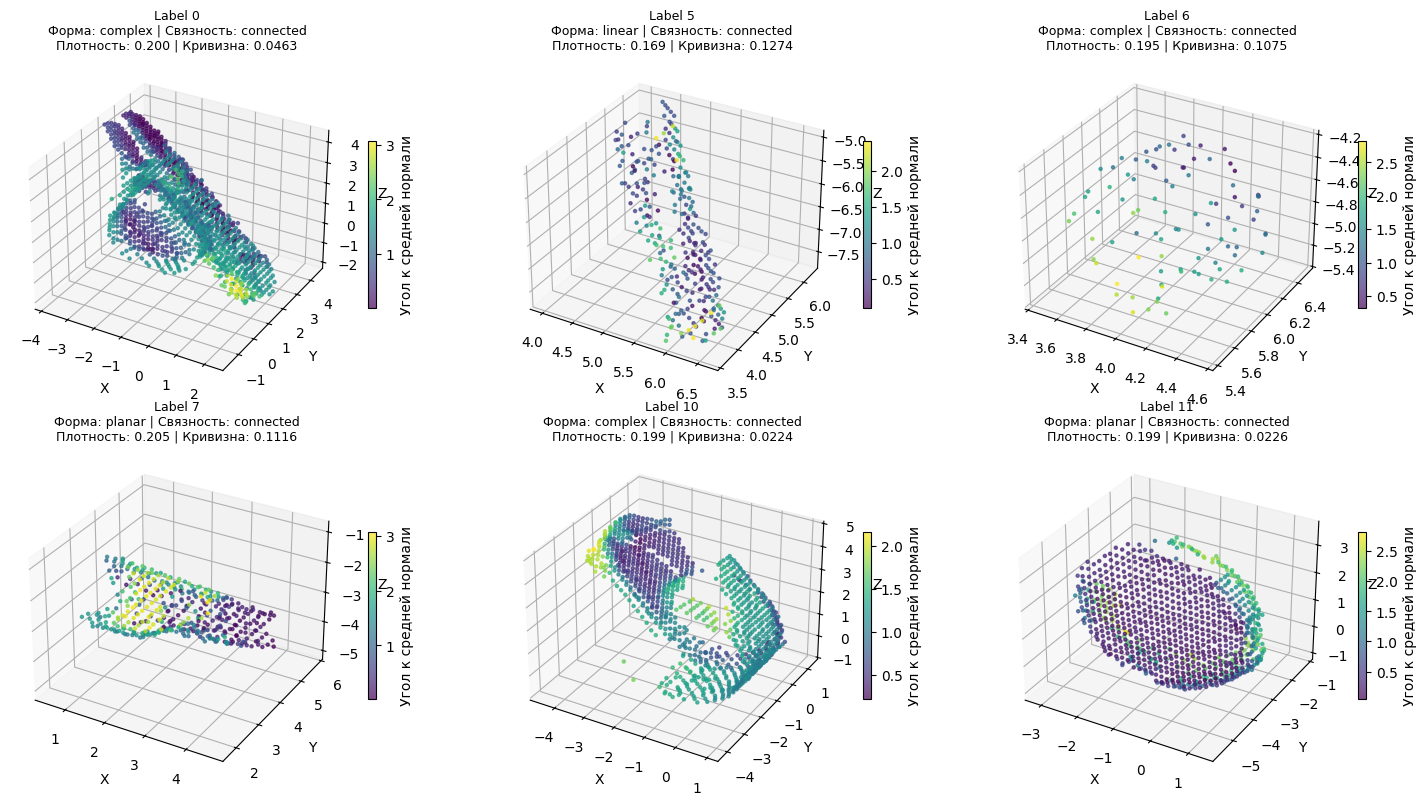

In [13]:


def plot_segment_characteristics(segments, segment_analysis, max_segments=6):
    """
    Визуализирует геометрические характеристики сегментов
    """
    # Выбираем сегменты для визуализации
    labels = sorted(segments.keys())[:max_segments]
    n_segments = len(labels)

    if n_segments == 0:
        print("Нет сегментов для визуализации")
        return

    # Определяем количество строк и столбцов
    n_cols = min(3, n_segments)
    n_rows = (n_segments + n_cols - 1) // n_cols

    fig = plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, label in enumerate(labels):
        if i >= max_segments:
            break

        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')

        seg_pts = segments[label]['points']
        geo = segment_analysis[label]

        # Цветовая кодировка по кривизне (если есть нормали)
        if geo.get('normals') is not None and len(geo['normals']) == len(seg_pts):
            # Используем вариацию нормалей как индикатор кривизны
            normals = geo['normals']
            # Вычисляем угол между нормалями и средней нормалью
            mean_normal = np.mean(normals, axis=0)
            mean_normal = mean_normal / (np.linalg.norm(mean_normal) + 1e-8)
            angles = np.arccos(np.clip(np.dot(normals, mean_normal), -1, 1))
            colors = angles
            scatter = ax.scatter(seg_pts[:, 0], seg_pts[:, 1], seg_pts[:, 2],
                               c=colors, cmap='viridis', s=5, alpha=0.7)
            plt.colorbar(scatter, ax=ax, shrink=0.5, label='Угол к средней нормали')
        else:
            # Простая цветовая кодировка по метке
            scatter = ax.scatter(seg_pts[:, 0], seg_pts[:, 1], seg_pts[:, 2],
                               c='blue', s=3, alpha=0.5)

        # Заголовок с характеристиками
        title = f"Label {label}\n"
        title += f"Форма: {geo['shape_type']} | Связность: {geo['connectivity']}\n"
        title += f"Плотность: {geo['density_mean']:.3f} | Кривизна: {geo['mean_curvature']:.4f}"
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        # Устанавливаем равные масштабы
        max_range = np.max([
            seg_pts[:, 0].max() - seg_pts[:, 0].min(),
            seg_pts[:, 1].max() - seg_pts[:, 1].min(),
            seg_pts[:, 2].max() - seg_pts[:, 2].min()
        ]) / 2.0
        mid_x = (seg_pts[:, 0].max() + seg_pts[:, 0].min()) * 0.5
        mid_y = (seg_pts[:, 1].max() + seg_pts[:, 1].min()) * 0.5
        mid_z = (seg_pts[:, 2].max() + seg_pts[:, 2].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.tight_layout()
    plt.show()

# Проверяем, что переменные существуют
print("Проверка наличия данных для визуализации...")
print(f"  files: {len(files) if 'files' in dir() else 'не определено'}")
print(f"  segment_analysis: {len(segment_analysis) if 'segment_analysis' in dir() else 'не определено'}")
print(f"  segments: {len(segments) if 'segments' in dir() else 'не определено'}")

# Визуализация
if 'files' in locals() and files and 'segment_analysis' in locals() and segment_analysis:
    print("\n🔍 Визуализация сегментов...")
    plot_segment_characteristics(segments, segment_analysis)
else:
    print("⚠️ Недостаточно данных для визуализации. Запустите сначала ячейки с загрузкой и анализом.")


🔍 Визуализация всех сегментов вместе...


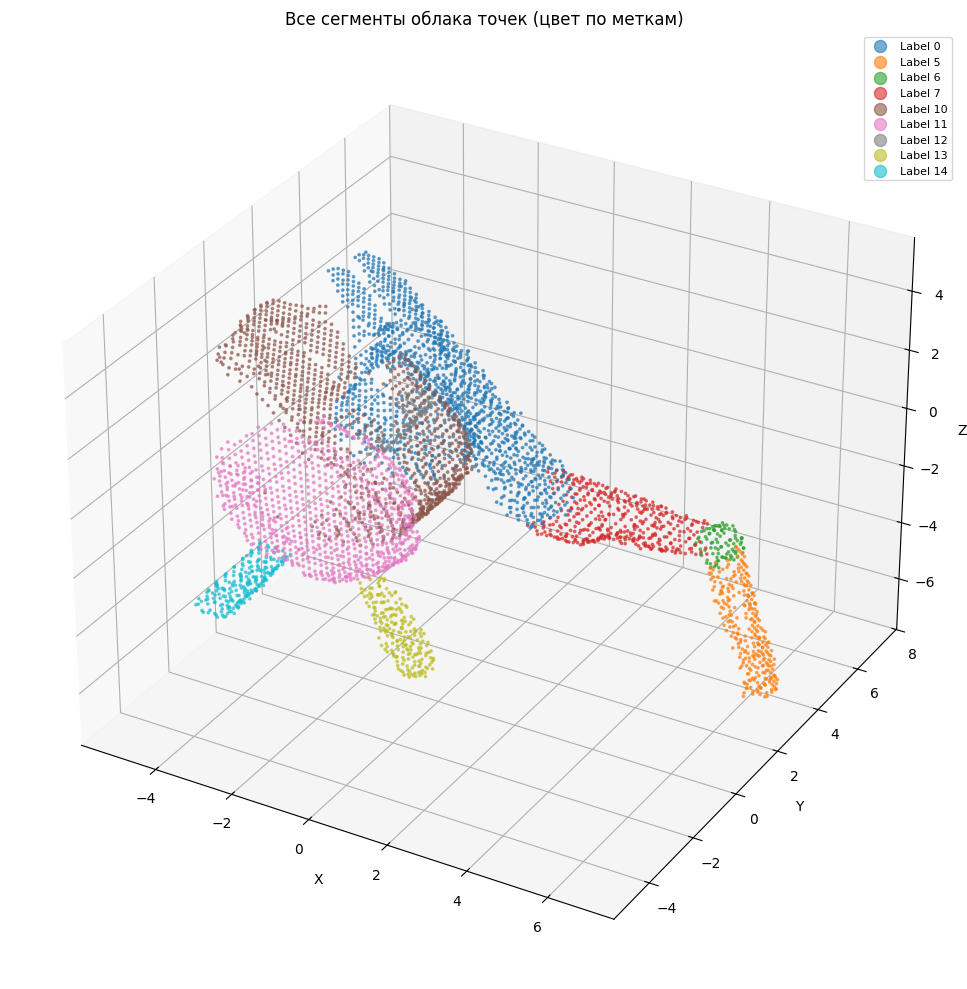

In [14]:
# 13.2 ВИЗУАЛИЗАЦИЯ ВСЕХ СЕГМЕНТОВ ВМЕСТЕ

def visualize_all_segments_together(segments, segment_analysis):
    """
    Визуализирует все сегменты вместе с цветовой кодировкой по меткам
    """
    if not segments:
        print("Нет сегментов для визуализации")
        return

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Цветовая карта для сегментов
    colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))

    for idx, (label, seg_data) in enumerate(sorted(segments.items())):
        seg_pts = seg_data['points']
        color = colors[idx % len(colors)]

        ax.scatter(seg_pts[:, 0], seg_pts[:, 1], seg_pts[:, 2],
                  c=[color], s=3, alpha=0.6, label=f'Label {label}')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Все сегменты облака точек (цвет по меткам)')
    ax.legend(markerscale=5, loc='upper right', fontsize=8)

    # Устанавливаем равные масштабы
    all_points = np.vstack([seg_data['points'] for seg_data in segments.values()])
    max_range = np.max([
        all_points[:, 0].max() - all_points[:, 0].min(),
        all_points[:, 1].max() - all_points[:, 1].min(),
        all_points[:, 2].max() - all_points[:, 2].min()
    ]) / 2.0
    mid_x = (all_points[:, 0].max() + all_points[:, 0].min()) * 0.5
    mid_y = (all_points[:, 1].max() + all_points[:, 1].min()) * 0.5
    mid_z = (all_points[:, 2].max() + all_points[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.tight_layout()
    plt.show()

# Визуализация всех сегментов вместе
if 'segments' in locals() and segments:
    print("\n🔍 Визуализация всех сегментов вместе...")
    visualize_all_segments_together(segments, segment_analysis)

In [15]:
# 14. СТАТИСТИКА ПО ВСЕМ СЕГМЕНТАМ ДАТАСЕТА

def analyze_all_segments(data_path, num_files=5, min_points=50):
    """
    Анализирует сегменты из нескольких файлов датасета
    """
    files = sorted(glob.glob(os.path.join(data_path, '*.ply')))[:num_files]

    all_stats = {
        'segment_counts': {},
        'class_counts': {},
        'method_counts': {},
        'shape_types': {},
        'connectivity': {},
        'size_distribution': [],
        'density_distribution': [],
        'curvature_distribution': [],
        'consistency_distribution': [],
        'per_file_stats': []
    }

    print(f"🔍 Анализ сегментов из {len(files)} файлов...")

    for filepath in tqdm(files, desc="Обработка"):
        try:
            points, labels = read_ply_pointcloud_with_labels(filepath)
            points_clean, labels_clean = preprocess_pointcloud(points, labels)
            segments = extract_segments_enhanced(points_clean, labels_clean, min_points=min_points)

            file_stats = {
                'filename': os.path.basename(filepath),
                'n_segments': len(segments),
                'classes': {}
            }

            for label, seg_data in segments.items():
                seg_pts = seg_data['points']
                geo = analyze_segment_geometry(seg_pts)

                if 'error' not in geo:
                    geo_class, method, confidence = classify_segment(geo)

                    # Собираем статистику
                    all_stats['segment_counts'][label] = all_stats['segment_counts'].get(label, 0) + 1
                    all_stats['class_counts'][geo_class] = all_stats['class_counts'].get(geo_class, 0) + 1
                    all_stats['method_counts'][method] = all_stats['method_counts'].get(method, 0) + 1
                    all_stats['shape_types'][geo['shape_type']] = all_stats['shape_types'].get(geo['shape_type'], 0) + 1
                    all_stats['connectivity'][geo['connectivity']] = all_stats['connectivity'].get(geo['connectivity'], 0) + 1

                    all_stats['size_distribution'].append(seg_data['n_points'])
                    all_stats['density_distribution'].append(geo['density_mean'])
                    all_stats['curvature_distribution'].append(geo['mean_curvature'])
                    all_stats['consistency_distribution'].append(geo['mean_consistency'])

                    file_stats['classes'][label] = geo_class
                else:
                    file_stats['classes'][label] = 'error'

            all_stats['per_file_stats'].append(file_stats)

        except Exception as e:
            print(f"⚠️ Ошибка при обработке {filepath}: {e}")

    return all_stats

# Запускаем анализ
print("\n" + "=" * 60)
print("СТАТИСТИКА ПО ВСЕМ СЕГМЕНТАМ")
print("=" * 60)

stats = analyze_all_segments(data_path, num_files=5, min_points=50)

if stats and stats['segment_counts']:
    total_segments = sum(stats['segment_counts'].values())
    print(f"\n📊 РЕЗУЛЬТАТЫ АНАЛИЗА:")
    print(f"  Всего сегментов: {total_segments}")

    print(f"\n  Распределение по меткам:")
    for label, count in sorted(stats['segment_counts'].items()):
        percentage = count / total_segments * 100
        print(f"    Label {label}: {count} сегментов ({percentage:.1f}%)")

    print(f"\n  Классы геометрии:")
    for cls, count in sorted(stats['class_counts'].items(), key=lambda x: -x[1]):
        percentage = count / total_segments * 100
        print(f"    {cls}: {count} ({percentage:.1f}%)")

    print(f"\n  Методы реконструкции:")
    for method, count in sorted(stats['method_counts'].items(), key=lambda x: -x[1]):
        percentage = count / total_segments * 100
        print(f"    {method}: {count} ({percentage:.1f}%)")

    print(f"\n  Типы формы (PCA):")
    for shape, count in sorted(stats['shape_types'].items(), key=lambda x: -x[1]):
        percentage = count / total_segments * 100
        print(f"    {shape}: {count} ({percentage:.1f}%)")

    print(f"\n  Топологическая связность:")
    for conn, count in sorted(stats['connectivity'].items(), key=lambda x: -x[1]):
        percentage = count / total_segments * 100
        print(f"    {conn}: {count} ({percentage:.1f}%)")

    # Сохраняем статистику в DataFrame для дальнейшего использования
    stats_df = pd.DataFrame({
        'Метка': list(stats['segment_counts'].keys()),
        'Количество': list(stats['segment_counts'].values())
    })
    stats_df = stats_df.sort_values('Метка')
    print(f"\n  Таблица распределения сегментов:")
    print(stats_df.to_string(index=False))


СТАТИСТИКА ПО ВСЕМ СЕГМЕНТАМ
🔍 Анализ сегментов из 5 файлов...


Обработка: 100%|██████████| 5/5 [00:14<00:00,  2.95s/it]


📊 РЕЗУЛЬТАТЫ АНАЛИЗА:
  Всего сегментов: 50

  Распределение по меткам:
    Label 0: 5 сегментов (10.0%)
    Label 3: 2 сегментов (4.0%)
    Label 4: 2 сегментов (4.0%)
    Label 5: 5 сегментов (10.0%)
    Label 6: 5 сегментов (10.0%)
    Label 7: 5 сегментов (10.0%)
    Label 10: 5 сегментов (10.0%)
    Label 11: 5 сегментов (10.0%)
    Label 12: 5 сегментов (10.0%)
    Label 13: 4 сегментов (8.0%)
    Label 14: 4 сегментов (8.0%)
    Label 15: 3 сегментов (6.0%)

  Классы геометрии:
    tubular: 26 (52.0%)
    planar: 13 (26.0%)
    complex: 11 (22.0%)

  Методы реконструкции:
    ball_pivoting: 20 (40.0%)
    poisson: 19 (38.0%)
    alpha_shape: 11 (22.0%)

  Типы формы (PCA):
    complex: 25 (50.0%)
    planar: 13 (26.0%)
    linear: 12 (24.0%)

  Топологическая связность:
    connected: 46 (92.0%)
    unknown: 2 (4.0%)
    few_components: 2 (4.0%)

  Таблица распределения сегментов:
 Метка  Количество
     0           5
     3           2
     4           2
     5           5
   

In [9]:
# 15. ФУНКЦИИ РЕКОНСТРУКЦИИ ПОВЕРХНОСТИ

def reconstruct_poisson(pts, depth=None):
    """
    Реконструкция методом Пуассона

    Args:
        pts (np.ndarray): массив координат (N, 3)
        depth (int): глубина октодерева

    Returns:
        tuple: (mesh, status)
    """
    try:
        if len(pts) < 50:
            return None, "Too few points"

        # Автоматический выбор глубины
        if depth is None:
            n = len(pts)
            if n < 100:
                depth = 5
            elif n < 300:
                depth = 6
            elif n < 1000:
                depth = 7
            else:
                depth = 8

        # Создаем open3d облако
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)

        # Оценка и ориентация нормалей
        pcd.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamKNN(min(30, len(pts) - 1))
        )
        pcd.orient_normals_consistent_tangent_plane(k=10)

        # Реконструкция Пуассона
        mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
            pcd, depth=depth
        )

        # Удаляем вершины с низкой плотностью (артефакты)
        if len(densities) > 0:
            densities = np.asarray(densities)
            density_threshold = np.percentile(densities, 20)
            vertices_to_remove = densities < density_threshold
            mesh.remove_vertices_by_mask(vertices_to_remove)

        # Упрощаем сетку для больших моделей
        if len(mesh.vertices) > 50000:
            mesh = mesh.simplify_quadric_decimation(
                target_number_of_triangles=30000
            )

        return mesh, "success"

    except Exception as e:
        return None, f"Poisson error: {str(e)}"

def reconstruct_ball_pivoting(pts):
    """
    Реконструкция методом катящегося шара (Ball Pivoting)

    Args:
        pts (np.ndarray): массив координат (N, 3)

    Returns:
        tuple: (mesh, status)
    """
    try:
        if len(pts) < 50:
            return None, "Too few points"

        # Создаем open3d облако
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)

        # Оценка нормалей
        pcd.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamKNN(min(20, len(pts) - 1))
        )
        pcd.orient_normals_consistent_tangent_plane(k=10)

        # Вычисляем среднее расстояние до соседей для автоматического выбора радиуса
        tree = KDTree(pts)
        k = min(10, len(pts))
        distances, _ = tree.query(pts, k=k)
        mean_nn = np.mean(distances[:, 1:])  # исключаем первую точку (саму себя)

        # Автоматический выбор радиусов
        radii = np.array([0.5, 1.0, 2.0, 4.0]) * mean_nn

        # Пытаемся реконструировать с разными радиусами
        mesh = None
        for radius in radii:
            try:
                mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
                    pcd, o3d.utility.DoubleVector([radius])
                )
                if len(mesh.triangles) > 10:
                    break
            except:
                continue

        if mesh is None or len(mesh.triangles) < 10:
            return None, "BPA failed - too few triangles"

        # Удаляем изолированные компоненты
        mesh.remove_degenerate_triangles()
        mesh.remove_duplicated_triangles()
        mesh.remove_duplicated_vertices()

        # Оставляем только самую большую компоненту
        triangle_clusters, cluster_n_triangles, _ = mesh.cluster_connected_triangles()
        if len(cluster_n_triangles) > 1:
            largest_cluster_idx = np.argmax(cluster_n_triangles)
            triangles_to_remove = []
            for i, cluster_idx in enumerate(triangle_clusters):
                if cluster_idx != largest_cluster_idx:
                    triangles_to_remove.append(i)
            mesh.remove_triangles_by_mask(triangles_to_remove)
            mesh.remove_unreferenced_vertices()

        return mesh, "success"

    except Exception as e:
        return None, f"BPA error: {str(e)}"

def reconstruct_alpha_shape(pts):
    """
    Реконструкция методом Alpha Shapes

    Args:
        pts (np.ndarray): массив координат (N, 3)

    Returns:
        tuple: (mesh, status)
    """
    try:
        if len(pts) < 20:
            return None, "Too few points"

        # Вычисляем среднее расстояние до соседей
        tree = KDTree(pts)
        k = min(8, len(pts))
        distances, _ = tree.query(pts, k=k)
        mean_nn = np.mean(distances[:, 1:])

        # Автоматический выбор alpha
        alpha = mean_nn * 4.0
        max_attempts = 3

        mesh = None
        for attempt in range(max_attempts):
            try:
                mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
                    o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pts)),
                    alpha
                )
                if len(mesh.triangles) > 10:
                    break
                alpha *= 1.5  # увеличиваем alpha для большего покрытия
            except:
                alpha *= 1.5
                continue

        if mesh is None or len(mesh.triangles) < 10:
            # Пробуем выпуклую оболочку как fallback
            try:
                mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
                    o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pts)),
                    alpha * 10
                )
                if len(mesh.triangles) > 10:
                    return mesh, "success (fallback)"
            except:
                pass
            return None, "AlphaShape failed"

        # Очистка сетки
        mesh.remove_degenerate_triangles()
        mesh.remove_duplicated_triangles()
        mesh.remove_duplicated_vertices()

        return mesh, "success"

    except Exception as e:
        return None, f"AlphaShape error: {str(e)}"

In [10]:
# 16. ОСНОВНАЯ ФУНКЦИЯ РЕКОНСТРУКЦИИ СЕГМЕНТА

def reconstruct_segment(pts, method):
    """
    Реконструирует сегмент выбранным методом

    Args:
        pts (np.ndarray): массив координат (N, 3)
        method (str): 'poisson', 'ball_pivoting', 'alpha_shape'

    Returns:
        tuple: (mesh, method_used, status)
    """
    # Проверяем минимальное количество точек
    if len(pts) < 20:
        return None, method, "Too few points (<20)"

    # Выбираем метод
    if method == 'poisson':
        mesh, status = reconstruct_poisson(pts)
    elif method == 'ball_pivoting':
        mesh, status = reconstruct_ball_pivoting(pts)
    elif method == 'alpha_shape':
        mesh, status = reconstruct_alpha_shape(pts)
    else:
        # Fallback на Alpha Shape
        mesh, status = reconstruct_alpha_shape(pts)
        method = 'alpha_shape'

    # Если основной метод не сработал, пробуем альтернативные
    if mesh is None or len(mesh.triangles) < 10:
        if method != 'alpha_shape':
            mesh, status2 = reconstruct_alpha_shape(pts)
            if mesh is not None and len(mesh.triangles) >= 10:
                method = 'alpha_shape'
                status = f"Fallback to alpha_shape: {status}"
        elif method != 'ball_pivoting':
            mesh, status2 = reconstruct_ball_pivoting(pts)
            if mesh is not None and len(mesh.triangles) >= 10:
                method = 'ball_pivoting'
                status = f"Fallback to ball_pivoting: {status}"

    return mesh, method, status

In [11]:
# 17. ФУНКЦИЯ ДЛЯ ОЦЕНКИ КАЧЕСТВА РЕКОНСТРУКЦИИ

def compute_reconstruction_quality(mesh, original_pts):
    """
    Вычисляет метрики качества реконструкции

    Args:
        mesh (open3d.geometry.TriangleMesh): реконструированная сетка
        original_pts (np.ndarray): исходное облако точек

    Returns:
        dict: метрики качества
    """
    if mesh is None or len(mesh.vertices) < 10:
        return {
            'error': 'Invalid mesh',
            'n_faces': 0,
            'n_vertices': 0
        }

    # Базовые метрики
    n_faces = len(mesh.triangles)
    n_vertices = len(mesh.vertices)

    # Преобразуем сетку в облако точек (вершины)
    mesh_vertices = np.asarray(mesh.vertices)

    if len(mesh_vertices) < 10 or len(original_pts) < 10:
        return {
            'error': 'Too few points',
            'n_faces': n_faces,
            'n_vertices': n_vertices
        }

    # Вычисляем расстояния (облако -> сетка)
    tree_mesh = KDTree(mesh_vertices)
    distances_cloud_to_mesh, _ = tree_mesh.query(original_pts)

    # Вычисляем расстояния (сетка -> облако)
    tree_cloud = KDTree(original_pts)
    distances_mesh_to_cloud, _ = tree_cloud.query(mesh_vertices)

    # Метрики
    cloud_to_mesh_rmse = np.sqrt(np.mean(distances_cloud_to_mesh**2))
    cloud_to_mesh_max = np.max(distances_cloud_to_mesh)
    cloud_to_mesh_mean = np.mean(distances_cloud_to_mesh)
    cloud_to_mesh_median = np.median(distances_cloud_to_mesh)

    mesh_to_cloud_rmse = np.sqrt(np.mean(distances_mesh_to_cloud**2))
    mesh_to_cloud_max = np.max(distances_mesh_to_cloud)
    mesh_to_cloud_mean = np.mean(distances_mesh_to_cloud)
    mesh_to_cloud_median = np.median(distances_mesh_to_cloud)

    # Расстояние Хаусдорфа (приближенное)
    hausdorff = max(cloud_to_mesh_max, mesh_to_cloud_max)

    # Анализ компонент связности
    try:
        triangle_clusters, cluster_n_triangles, _ = mesh.cluster_connected_triangles()
        n_components = len(cluster_n_triangles)
        if n_components > 0:
            largest_comp_ratio = max(cluster_n_triangles) / n_faces
        else:
            largest_comp_ratio = 0
    except:
        n_components = 1
        largest_comp_ratio = 1.0

    # Объем и площадь
    try:
        volume = mesh.get_volume()
        surface_area = mesh.get_surface_area()
    except:
        volume = 0
        surface_area = 0

    return {
        'n_faces': n_faces,
        'n_vertices': n_vertices,
        'cloud_to_mesh_rmse': cloud_to_mesh_rmse,
        'cloud_to_mesh_max': cloud_to_mesh_max,
        'cloud_to_mesh_mean': cloud_to_mesh_mean,
        'cloud_to_mesh_median': cloud_to_mesh_median,
        'mesh_to_cloud_rmse': mesh_to_cloud_rmse,
        'mesh_to_cloud_max': mesh_to_cloud_max,
        'mesh_to_cloud_mean': mesh_to_cloud_mean,
        'mesh_to_cloud_median': mesh_to_cloud_median,
        'hausdorff_approx': hausdorff,
        'n_components': n_components,
        'largest_comp_ratio': largest_comp_ratio,
        'volume': volume,
        'surface_area': surface_area
    }

In [12]:
# 18. ФУНКЦИЯ ДЛЯ ОБРАБОТКИ ОДНОГО ФАЙЛА (ПОЛНЫЙ PIPELINE)

def process_single_file(filepath, min_points=50, visualize=True):
    """
    Полная обработка одного файла

    Args:
        filepath (str): путь к PLY файлу
        min_points (int): минимальное количество точек в сегменте
        visualize (bool): показывать ли визуализацию

    Returns:
        dict: результаты обработки
    """
    print(f"\n{'='*60}")
    print(f"ОБРАБОТКА ФАЙЛА: {os.path.basename(filepath)}")
    print(f"{'='*60}")

    try:
        # 1. Загрузка
        print("1. Загрузка данных...")
        points, labels = read_ply_pointcloud_with_labels(filepath)
        print(f"   Загружено {len(points):,} точек, {len(np.unique(labels))} сегментов")

        # 2. Предобработка
        print("2. Предобработка...")
        points_clean, labels_clean = preprocess_pointcloud(points, labels)
        print(f"   После предобработки: {len(points_clean):,} точек")

        # 3. Извлечение сегментов
        print("3. Извлечение сегментов...")
        segments = extract_segments_enhanced(points_clean, labels_clean, min_points=min_points)
        print(f"   Извлечено {len(segments)} сегментов")

        # 4. Анализ и реконструкция каждого сегмента
        print("4. Геометрический анализ и реконструкция...")

        all_meshes = {}
        all_metrics = {}
        all_classifications = {}

        for label, seg_data in tqdm(segments.items(), desc="   Обработка сегментов"):
            seg_pts = seg_data['points']

            # Геометрический анализ
            geo = analyze_segment_geometry(seg_pts)
            if 'error' in geo:
                print(f"   ⚠️ Сегмент {label}: ошибка анализа")
                continue

            # Классификация
            geo_class, method, confidence = classify_segment(geo)
            all_classifications[label] = {
                'class': geo_class,
                'method': method,
                'confidence': confidence,
                'geo': geo
            }

            # Реконструкция
            mesh, method_used, status = reconstruct_segment(seg_pts, method)

            if mesh is not None and len(mesh.triangles) > 10:
                all_meshes[label] = mesh

                # Оценка качества
                metrics = compute_reconstruction_quality(mesh, seg_pts)
                all_metrics[label] = metrics
                all_metrics[label]['method_used'] = method_used
                all_metrics[label]['status'] = status

                print(f"   ✅ Сегмент {label}: {geo_class} -> {method_used.upper()}, "
                      f"{len(mesh.triangles):,} граней, RMSE={metrics['cloud_to_mesh_rmse']:.4f}")
            else:
                print(f"   ⚠️ Сегмент {label}: реконструкция не удалась ({status})")

        # 5. Сборка модели
        print("5. Сборка модели...")
        if all_meshes:
            combined_mesh = o3d.geometry.TriangleMesh()
            for label, mesh in all_meshes.items():
                combined_mesh += mesh

            # Очистка итоговой модели
            combined_mesh.remove_degenerate_triangles()
            combined_mesh.remove_duplicated_triangles()
            combined_mesh.remove_duplicated_vertices()

            print(f"   Итоговая модель: {len(combined_mesh.vertices):,} вершин, "
                  f"{len(combined_mesh.triangles):,} граней")
        else:
            combined_mesh = None
            print("   ⚠️ Нет сегментов для сборки")

        # 6. Визуализация (опционально)
        if visualize and combined_mesh is not None and len(combined_mesh.vertices) > 0:
            print("6. Визуализация...")

            fig = plt.figure(figsize=(12, 8))
            ax = fig.add_subplot(111, projection='3d')

            # Визуализируем сетку
            vertices = np.asarray(combined_mesh.vertices)
            triangles = np.asarray(combined_mesh.triangles)

            ax.plot_trisurf(vertices[:, 0], vertices[:, 1], vertices[:, 2],
                          triangles=triangles, alpha=0.7, cmap='viridis')

            # Добавляем исходные точки для сравнения
            ax.scatter(points_clean[:, 0], points_clean[:, 1], points_clean[:, 2],
                      c='red', s=1, alpha=0.3)

            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.set_title(f'Реконструкция: {os.path.basename(filepath)}')

            # Устанавливаем равные масштабы
            all_points = np.vstack([vertices, points_clean])
            max_range = np.max([
                all_points[:, 0].max() - all_points[:, 0].min(),
                all_points[:, 1].max() - all_points[:, 1].min(),
                all_points[:, 2].max() - all_points[:, 2].min()
            ]) / 2.0
            mid_x = (all_points[:, 0].max() + all_points[:, 0].min()) * 0.5
            mid_y = (all_points[:, 1].max() + all_points[:, 1].min()) * 0.5
            mid_z = (all_points[:, 2].max() + all_points[:, 2].min()) * 0.5
            ax.set_xlim(mid_x - max_range, mid_x + max_range)
            ax.set_ylim(mid_y - max_range, mid_y + max_range)
            ax.set_zlim(mid_z - max_range, mid_z + max_range)

            plt.tight_layout()
            plt.show()

        # 7. Сборка результатов
        results = {
            'filename': os.path.basename(filepath),
            'n_points_original': len(points),
            'n_points_clean': len(points_clean),
            'n_segments': len(segments),
            'segments': segments,
            'meshes': all_meshes,
            'metrics': all_metrics,
            'classifications': all_classifications,
            'combined_mesh': combined_mesh,
            'status': 'success'
        }

        # Вывод сводки
        print(f"\n{'='*60}")
        print(f"✅ ОБРАБОТКА ЗАВЕРШЕНА")
        print(f"{'='*60}")
        print(f"  Обработано сегментов: {len(all_meshes)}/{len(segments)}")
        print(f"  Итоговая модель: {len(combined_mesh.vertices) if combined_mesh else 0} вершин")

        return results

    except Exception as e:
        print(f"❌ Ошибка при обработке файла: {e}")
        import traceback
        traceback.print_exc()
        return {'status': 'error', 'error': str(e)}


ОБРАБОТКА ФАЙЛА: valve_0001_lidar_classes.ply
1. Загрузка данных...
   Загружено 4,899 точек, 16 сегментов
2. Предобработка...
   После предобработки: 4,721 точек
3. Извлечение сегментов...
   Извлечено 9 сегментов
4. Геометрический анализ и реконструкция...


   Обработка сегментов:  22%|██▏       | 2/9 [00:01<00:04,  1.47it/s]

   ✅ Сегмент 0: complex -> POISSON, 7,118 граней, RMSE=0.0803
   ✅ Сегмент 5: tubular -> ALPHA_SHAPE, 366 граней, RMSE=0.0752
   ✅ Сегмент 6: complex -> ALPHA_SHAPE, 132 граней, RMSE=0.0808


   Обработка сегментов:  44%|████▍     | 4/9 [00:03<00:03,  1.36it/s]

   ✅ Сегмент 7: planar -> POISSON, 3,076 граней, RMSE=0.1154


...

   ✅ Сегмент 10: complex -> POISSON, 6,931 граней, RMSE=0.0797


   Обработка сегментов:  89%|████████▉ | 8/9 [00:07<00:00,  1.25it/s]

   ✅ Сегмент 11: planar -> POISSON, 4,130 граней, RMSE=0.0804
   ✅ Сегмент 12: tubular -> ALPHA_SHAPE, 128 граней, RMSE=0.0690
   ✅ Сегмент 13: tubular -> ALPHA_SHAPE, 240 граней, RMSE=0.1040


   Обработка сегментов: 100%|██████████| 9/9 [00:08<00:00,  1.12it/s]


   ✅ Сегмент 14: tubular -> ALPHA_SHAPE, 242 граней, RMSE=0.1133
5. Сборка модели...
   Итоговая модель: 11,526 вершин, 22,363 граней
6. Визуализация...


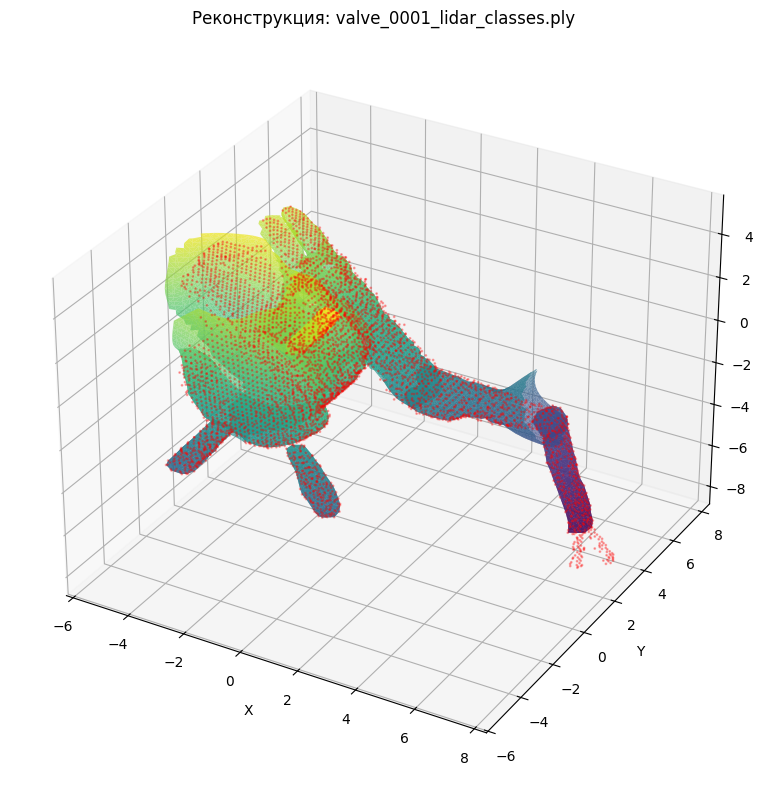


✅ ОБРАБОТКА ЗАВЕРШЕНА
  Обработано сегментов: 9/9
  Итоговая модель: 11526 вершин

📊 СВОДКА РЕЗУЛЬТАТОВ:
  Файл: valve_0001_lidar_classes.ply
  Сегментов обработано: 9

  Метрики по сегментам:
    Label 0: RMSE=0.0803, граней=7118, метод=poisson
    Label 5: RMSE=0.0752, граней=366, метод=alpha_shape
    Label 6: RMSE=0.0808, граней=132, метод=alpha_shape
    Label 7: RMSE=0.1154, граней=3076, метод=poisson
    Label 10: RMSE=0.0797, граней=6931, метод=poisson
    Label 11: RMSE=0.0804, граней=4130, метод=poisson
    Label 12: RMSE=0.0690, граней=128, метод=alpha_shape
    Label 13: RMSE=0.1040, граней=240, метод=alpha_shape
    Label 14: RMSE=0.1133, граней=242, метод=alpha_shape

  Распределение методов:
    poisson: 4 сегментов
    alpha_shape: 5 сегментов


In [23]:
# 19. ТЕСТИРОВАНИЕ НА ОДНОМ ФАЙЛЕ

if files:
    # Берем первый файл для теста
    test_file = files[0]

    # Обрабатываем файл
    results = process_single_file(test_file, min_points=50, visualize=True)

    if results['status'] == 'success':
        print(f"\n📊 СВОДКА РЕЗУЛЬТАТОВ:")
        print(f"  Файл: {results['filename']}")
        print(f"  Сегментов обработано: {len(results['meshes'])}")

        # Вывод метрик по сегментам
        print(f"\n  Метрики по сегментам:")
        for label, metrics in sorted(results['metrics'].items()):
            if 'error' not in metrics:
                print(f"    Label {label}: RMSE={metrics['cloud_to_mesh_rmse']:.4f}, "
                      f"граней={metrics['n_faces']}, метод={metrics.get('method_used', 'unknown')}")

        # Статистика по методам
        method_counts = {}
        for label, metrics in results['metrics'].items():
            if 'method_used' in metrics:
                method = metrics['method_used']
                method_counts[method] = method_counts.get(method, 0) + 1

        print(f"\n  Распределение методов:")
        for method, count in method_counts.items():
            print(f"    {method}: {count} сегментов")

In [13]:
# 20. ПАКЕТНАЯ ОБРАБОТКА НЕСКОЛЬКИХ ФАЙЛОВ

def batch_process_files(data_path, num_files=3, min_points=50):
    """
    Пакетная обработка нескольких файлов

    Args:
        data_path (str): путь к папке с данными
        num_files (int): количество файлов для обработки
        min_points (int): минимальное количество точек в сегменте

    Returns:
        list: результаты обработки
    """
    files = sorted(glob.glob(os.path.join(data_path, '*.ply')))[:num_files]

    if not files:
        print("Нет файлов для обработки")
        return []

    print(f"\n{'='*60}")
    print(f"ПАКЕТНАЯ ОБРАБОТКА {len(files)} ФАЙЛОВ")
    print(f"{'='*60}")

    all_results = []

    for i, filepath in enumerate(files, 1):
        print(f"\n[{i}/{len(files)}] Обработка: {os.path.basename(filepath)}")
        results = process_single_file(filepath, min_points=min_points, visualize=False)
        all_results.append(results)

    # Общая статистика
    print(f"\n{'='*60}")
    print("ИТОГОВАЯ СТАТИСТИКА")
    print(f"{'='*60}")

    successful = sum(1 for r in all_results if r['status'] == 'success')
    total_segments = sum(len(r.get('meshes', {})) for r in all_results if r['status'] == 'success')
    total_faces = 0
    total_vertices = 0

    for r in all_results:
        if r['status'] == 'success' and r.get('combined_mesh'):
            total_faces += len(r['combined_mesh'].triangles)
            total_vertices += len(r['combined_mesh'].vertices)

    print(f"  Успешно обработано: {successful}/{len(files)} файлов")
    print(f"  Всего сегментов: {total_segments}")
    print(f"  Среднее граней на модель: {total_faces/successful if successful else 0:.0f}")
    print(f"  Среднее вершин на модель: {total_vertices/successful if successful else 0:.0f}")

    return all_results

# Запускаем пакетную обработку (начнем с 3 файлов для теста)
batch_results = batch_process_files(data_path, num_files=3, min_points=50)


ПАКЕТНАЯ ОБРАБОТКА 3 ФАЙЛОВ

[1/3] Обработка: valve_0001_lidar_classes.ply

ОБРАБОТКА ФАЙЛА: valve_0001_lidar_classes.ply
1. Загрузка данных...
   Загружено 4,899 точек, 16 сегментов
2. Предобработка...
   После предобработки: 4,721 точек
3. Извлечение сегментов...
   Извлечено 9 сегментов
4. Геометрический анализ и реконструкция...


   Обработка сегментов:  11%|█         | 1/9 [00:04<00:39,  4.97s/it]

   ✅ Сегмент 0: complex -> POISSON, 7,118 граней, RMSE=0.0803


   Обработка сегментов:  22%|██▏       | 2/9 [00:05<00:15,  2.20s/it]

   ✅ Сегмент 5: tubular -> ALPHA_SHAPE, 366 граней, RMSE=0.0752
   ✅ Сегмент 6: complex -> ALPHA_SHAPE, 132 граней, RMSE=0.0808


...

   ✅ Сегмент 10: planar -> POISSON, 6,698 граней, RMSE=0.0787


   Обработка сегментов:  73%|███████▎  | 8/11 [00:05<00:02,  1.20it/s]

   ✅ Сегмент 11: planar -> POISSON, 4,572 граней, RMSE=0.0755
   ✅ Сегмент 12: tubular -> ALPHA_SHAPE, 304 граней, RMSE=0.0836


   Обработка сегментов: 100%|██████████| 11/11 [00:06<00:00,  1.76it/s]

   ✅ Сегмент 13: tubular -> ALPHA_SHAPE, 266 граней, RMSE=0.0945
   ✅ Сегмент 14: tubular -> ALPHA_SHAPE, 118 граней, RMSE=0.0958
   ✅ Сегмент 15: tubular -> ALPHA_SHAPE, 206 граней, RMSE=0.0979
5. Сборка модели...
   Итоговая модель: 8,695 вершин, 17,050 граней

✅ ОБРАБОТКА ЗАВЕРШЕНА
  Обработано сегментов: 11/11
  Итоговая модель: 8695 вершин

ИТОГОВАЯ СТАТИСТИКА
  Успешно обработано: 3/3 файлов
  Всего сегментов: 31
  Среднее граней на модель: 20806
  Среднее вершин на модель: 10706


In [26]:
# ============================================
# 6. ПАКЕТНАЯ ОБРАБОТКА ВСЕХ ФАЙЛОВ
# ============================================

def batch_process_all_files(data_path, min_points=50, max_files=None, save_results=True):
    """
    Пакетная обработка всех файлов в папке

    Args:
        data_path (str): путь к папке с данными
        min_points (int): минимальное количество точек в сегменте
        max_files (int): максимальное количество файлов для обработки
        save_results (bool): сохранять ли результаты

    Returns:
        dict: результаты обработки всех файлов
    """
    files = sorted(glob.glob(os.path.join(data_path, '*.ply')))

    if max_files:
        files = files[:max_files]

    if not files:
        print("❌ Нет файлов для обработки")
        return None

    print(f"\n{'='*60}")
    print(f"ПАКЕТНАЯ ОБРАБОТКА {len(files)} ФАЙЛОВ")
    print(f"{'='*60}")

    all_results = []
    start_time = time.time()

    # Статистика для всего датасета
    global_stats = {
        'total_files': len(files),
        'processed_files': 0,
        'total_segments': 0,
        'total_meshes': 0,
        'method_counts': {},
        'class_counts': {},
        'shape_types': {},
        'connectivity': {},
        'all_rmse': [],
        'all_faces': [],
        'all_vertices': [],
        'per_file_stats': []
    }

    for i, filepath in enumerate(files, 1):
        print(f"\n[{i}/{len(files)}] Обработка: {os.path.basename(filepath)}")

        try:
            # Обрабатываем файл без визуализации для скорости
            results = process_single_file(filepath, min_points=min_points, visualize=False)
            all_results.append(results)

            if results['status'] == 'success':
                global_stats['processed_files'] += 1
                global_stats['total_segments'] += results['n_segments']
                global_stats['total_meshes'] += len(results['meshes'])

                # Собираем статистику по методам и классам
                for label, metrics in results['metrics'].items():
                    if 'method_used' in metrics:
                        method = metrics['method_used']
                        global_stats['method_counts'][method] = global_stats['method_counts'].get(method, 0) + 1

                        if 'cloud_to_mesh_rmse' in metrics:
                            global_stats['all_rmse'].append(metrics['cloud_to_mesh_rmse'])
                        if 'n_faces' in metrics:
                            global_stats['all_faces'].append(metrics['n_faces'])
                        if 'n_vertices' in metrics:
                            global_stats['all_vertices'].append(metrics['n_vertices'])

                for label, class_info in results['classifications'].items():
                    geo_class = class_info['class']
                    global_stats['class_counts'][geo_class] = global_stats['class_counts'].get(geo_class, 0) + 1

                    shape_type = class_info['geo']['shape_type']
                    global_stats['shape_types'][shape_type] = global_stats['shape_types'].get(shape_type, 0) + 1

                    connectivity = class_info['geo']['connectivity']
                    global_stats['connectivity'][connectivity] = global_stats['connectivity'].get(connectivity, 0) + 1

                # Статистика по файлу
                file_stats = {
                    'filename': results['filename'],
                    'n_segments': results['n_segments'],
                    'n_meshes': len(results['meshes']),
                    'n_vertices': len(results['combined_mesh'].vertices) if results['combined_mesh'] else 0,
                    'n_faces': len(results['combined_mesh'].triangles) if results['combined_mesh'] else 0,
                    'methods': {}
                }
                for label, metrics in results['metrics'].items():
                    if 'method_used' in metrics:
                        method = metrics['method_used']
                        file_stats['methods'][method] = file_stats['methods'].get(method, 0) + 1
                global_stats['per_file_stats'].append(file_stats)

        except Exception as e:
            print(f"❌ Ошибка при обработке {os.path.basename(filepath)}: {e}")
            all_results.append({'status': 'error', 'filename': os.path.basename(filepath), 'error': str(e)})

    elapsed_time = time.time() - start_time

    # Итоговая статистика
    print(f"\n{'='*60}")
    print("ИТОГОВАЯ СТАТИСТИКА")
    print(f"{'='*60}")
    print(f"  Всего файлов: {global_stats['total_files']}")
    print(f"  Успешно обработано: {global_stats['processed_files']}")
    print(f"  Всего сегментов: {global_stats['total_segments']}")
    print(f"  Всего реконструировано: {global_stats['total_meshes']}")
    print(f"  Время обработки: {elapsed_time/60:.1f} мин ({elapsed_time/global_stats['total_files']:.1f} сек/файл)")

    if global_stats['all_rmse']:
        print(f"\n  📊 Метрики качества:")
        print(f"    Средний RMSE: {np.mean(global_stats['all_rmse']):.4f} ± {np.std(global_stats['all_rmse']):.4f}")
        print(f"    Медианный RMSE: {np.median(global_stats['all_rmse']):.4f}")
        print(f"    Минимальный RMSE: {np.min(global_stats['all_rmse']):.4f}")
        print(f"    Максимальный RMSE: {np.max(global_stats['all_rmse']):.4f}")

    if global_stats['all_faces']:
        print(f"\n  📐 Размеры моделей:")
        print(f"    Среднее граней: {np.mean(global_stats['all_faces']):.0f}")
        print(f"    Медиана граней: {np.median(global_stats['all_faces']):.0f}")
        print(f"    Среднее вершин: {np.mean(global_stats['all_vertices']):.0f}")
        print(f"    Медиана вершин: {np.median(global_stats['all_vertices']):.0f}")

    print(f"\n  📌 Распределение методов реконструкции:")
    for method, count in sorted(global_stats['method_counts'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_meshes'] * 100 if global_stats['total_meshes'] > 0 else 0
        print(f"    {method}: {count} сегментов ({percentage:.1f}%)")

    print(f"\n  📌 Классы геометрии:")
    for cls, count in sorted(global_stats['class_counts'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_segments'] * 100 if global_stats['total_segments'] > 0 else 0
        print(f"    {cls}: {count} сегментов ({percentage:.1f}%)")

    print(f"\n  📌 Типы формы (PCA):")
    for shape, count in sorted(global_stats['shape_types'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_segments'] * 100 if global_stats['total_segments'] > 0 else 0
        print(f"    {shape}: {count} сегментов ({percentage:.1f}%)")

    print(f"\n  📌 Топологическая связность:")
    for conn, count in sorted(global_stats['connectivity'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_segments'] * 100 if global_stats['total_segments'] > 0 else 0
        print(f"    {conn}: {count} сегментов ({percentage:.1f}%)")

    # Сохраняем результаты
    if save_results:
        results_summary = {
            'global_stats': global_stats,
            'all_results': all_results,
            'elapsed_time': elapsed_time
        }
        np.save('/content/batch_results.npy', results_summary)
        print(f"\n💾 Результаты сохранены в batch_results.npy")

    return global_stats, all_results

# Запускаем обработку всех файлов (можно ограничить количество)
print("Начинаем пакетную обработку...")
global_stats, all_results = batch_process_all_files(
    data_path,
    min_points=50,
    save_results=True
)

Начинаем пакетную обработку...

ПАКЕТНАЯ ОБРАБОТКА 503 ФАЙЛОВ

[1/503] Обработка: valve_0001_lidar_classes.ply

ОБРАБОТКА ФАЙЛА: valve_0001_lidar_classes.ply
1. Загрузка данных...
   Загружено 4,899 точек, 16 сегментов
2. Предобработка...
   После предобработки: 4,721 точек
3. Извлечение сегментов...
   Извлечено 9 сегментов
4. Геометрический анализ и реконструкция...


   Обработка сегментов:  22%|██▏       | 2/9 [00:05<00:15,  2.20s/it]

   ✅ Сегмент 0: complex -> POISSON, 7,118 граней, RMSE=0.0803
   ✅ Сегмент 5: tubular -> ALPHA_SHAPE, 366 граней, RMSE=0.0752
   ✅ Сегмент 6: complex -> ALPHA_SHAPE, 132 граней, RMSE=0.0808


   Обработка сегментов:  44%|████▍     | 4/9 [00:06<00:05,  1.11s/it]

   ✅ Сегмент 7: planar -> POISSON, 3,076 граней, RMSE=0.1154


...

   Обработка сегментов:  80%|████████  | 8/10 [00:04<00:00,  2.31it/s]

   ✅ Сегмент 13: tubular -> ALPHA_SHAPE, 170 граней, RMSE=0.1130
   ✅ Сегмент 14: tubular -> ALPHA_SHAPE, 108 граней, RMSE=0.1065


   Обработка сегментов: 100%|██████████| 10/10 [00:04<00:00,  2.18it/s]

   ✅ Сегмент 15: tubular -> ALPHA_SHAPE, 212 граней, RMSE=0.0993
5. Сборка модели...
   Итоговая модель: 9,677 вершин, 18,969 граней

✅ ОБРАБОТКА ЗАВЕРШЕНА
  Обработано сегментов: 10/10
  Итоговая модель: 9677 вершин

ИТОГОВАЯ СТАТИСТИКА
  Всего файлов: 503
  Успешно обработано: 503
  Всего сегментов: 4993
  Всего реконструировано: 4993
  Время обработки: 53.7 мин (6.4 сек/файл)

  📊 Метрики качества:
    Средний RMSE: 0.0840 ± 0.0240
    Медианный RMSE: 0.0842
    Минимальный RMSE: 0.0000
    Максимальный RMSE: 0.1812

  📐 Размеры моделей:
    Среднее граней: 2066
    Медиана граней: 354
    Среднее вершин: 1064
    Медиана вершин: 179

  📌 Распределение методов реконструкции:
    alpha_shape: 3246 сегментов (65.0%)
    poisson: 1745 сегментов (34.9%)
    ball_pivoting: 2 сегментов (0.0%)

  📌 Классы геометрии:
    tubular: 2788 сегментов (55.8%)
    complex: 1196 сегментов (24.0%)
    planar: 999 сегментов (20.0%)
    spherical: 10 сегментов (0.2%)

  📌 Типы формы (PCA):
    complex:

TypeError: cannot pickle 'open3d.cuda.pybind.geometry.TriangleMesh' object

In [15]:
# ============================================
# 6. ПАКЕТНАЯ ОБРАБОТКА ВСЕХ ФАЙЛОВ (ИСПРАВЛЕННАЯ)
# ============================================

def batch_process_all_files(data_path, min_points=50, max_files=None, save_results=True):
    """
    Пакетная обработка всех файлов в папке

    Args:
        data_path (str): путь к папке с данными
        min_points (int): минимальное количество точек в сегменте
        max_files (int): максимальное количество файлов для обработки
        save_results (bool): сохранять ли результаты

    Returns:
        dict: результаты обработки всех файлов
    """
    files = sorted(glob.glob(os.path.join(data_path, '*.ply')))

    if max_files:
        files = files[:max_files]

    if not files:
        print("❌ Нет файлов для обработки")
        return None, None

    print(f"\n{'='*60}")
    print(f"ПАКЕТНАЯ ОБРАБОТКА {len(files)} ФАЙЛОВ")
    print(f"{'='*60}")

    all_results = []
    start_time = time.time()

    # Статистика для всего датасета
    global_stats = {
        'total_files': len(files),
        'processed_files': 0,
        'total_segments': 0,
        'total_meshes': 0,
        'method_counts': {},
        'class_counts': {},
        'shape_types': {},
        'connectivity': {},
        'all_rmse': [],
        'all_faces': [],
        'all_vertices': [],
        'per_file_stats': []
    }

    for i, filepath in enumerate(files, 1):
        print(f"\n[{i}/{len(files)}] Обработка: {os.path.basename(filepath)}")

        try:
            # Обрабатываем файл без визуализации для скорости
            results = process_single_file(filepath, min_points=min_points, visualize=False)

            # Создаем упрощенную версию результатов без mesh объектов для сохранения
            results_light = {
                'filename': results['filename'],
                'status': results['status'],
                'n_points_original': results.get('n_points_original', 0),
                'n_points_clean': results.get('n_points_clean', 0),
                'n_segments': results.get('n_segments', 0),
                'n_meshes': len(results.get('meshes', {})),
                'metrics': results.get('metrics', {}),
                'classifications': results.get('classifications', {}),
            }

            # Добавляем информацию о размерах модели
            if results.get('combined_mesh') is not None:
                results_light['n_vertices'] = len(results['combined_mesh'].vertices)
                results_light['n_faces'] = len(results['combined_mesh'].triangles)
            else:
                results_light['n_vertices'] = 0
                results_light['n_faces'] = 0

            all_results.append(results_light)

            if results['status'] == 'success':
                global_stats['processed_files'] += 1
                global_stats['total_segments'] += results['n_segments']
                global_stats['total_meshes'] += len(results['meshes'])

                # Собираем статистику по методам и классам
                for label, metrics in results['metrics'].items():
                    if 'method_used' in metrics:
                        method = metrics['method_used']
                        global_stats['method_counts'][method] = global_stats['method_counts'].get(method, 0) + 1

                        if 'cloud_to_mesh_rmse' in metrics:
                            global_stats['all_rmse'].append(metrics['cloud_to_mesh_rmse'])
                        if 'n_faces' in metrics:
                            global_stats['all_faces'].append(metrics['n_faces'])
                        if 'n_vertices' in metrics:
                            global_stats['all_vertices'].append(metrics['n_vertices'])

                for label, class_info in results['classifications'].items():
                    geo_class = class_info['class']
                    global_stats['class_counts'][geo_class] = global_stats['class_counts'].get(geo_class, 0) + 1

                    shape_type = class_info['geo']['shape_type']
                    global_stats['shape_types'][shape_type] = global_stats['shape_types'].get(shape_type, 0) + 1

                    connectivity = class_info['geo']['connectivity']
                    global_stats['connectivity'][connectivity] = global_stats['connectivity'].get(connectivity, 0) + 1

                # Статистика по файлу
                file_stats = {
                    'filename': results['filename'],
                    'n_segments': results['n_segments'],
                    'n_meshes': len(results['meshes']),
                    'n_vertices': results_light['n_vertices'],
                    'n_faces': results_light['n_faces'],
                    'methods': {}
                }
                for label, metrics in results['metrics'].items():
                    if 'method_used' in metrics:
                        method = metrics['method_used']
                        file_stats['methods'][method] = file_stats['methods'].get(method, 0) + 1
                global_stats['per_file_stats'].append(file_stats)

        except Exception as e:
            print(f"❌ Ошибка при обработке {os.path.basename(filepath)}: {e}")
            all_results.append({
                'status': 'error',
                'filename': os.path.basename(filepath),
                'error': str(e)
            })

    elapsed_time = time.time() - start_time

    # Итоговая статистика
    print(f"\n{'='*60}")
    print("ИТОГОВАЯ СТАТИСТИКА")
    print(f"{'='*60}")
    print(f"  Всего файлов: {global_stats['total_files']}")
    print(f"  Успешно обработано: {global_stats['processed_files']}")
    print(f"  Всего сегментов: {global_stats['total_segments']}")
    print(f"  Всего реконструировано: {global_stats['total_meshes']}")
    print(f"  Время обработки: {elapsed_time/60:.1f} мин ({elapsed_time/global_stats['total_files']:.1f} сек/файл)")

    if global_stats['all_rmse']:
        print(f"\n  📊 Метрики качества:")
        print(f"    Средний RMSE: {np.mean(global_stats['all_rmse']):.4f} ± {np.std(global_stats['all_rmse']):.4f}")
        print(f"    Медианный RMSE: {np.median(global_stats['all_rmse']):.4f}")
        print(f"    Минимальный RMSE: {np.min(global_stats['all_rmse']):.4f}")
        print(f"    Максимальный RMSE: {np.max(global_stats['all_rmse']):.4f}")

    if global_stats['all_faces']:
        print(f"\n  📐 Размеры моделей:")
        print(f"    Среднее граней: {np.mean(global_stats['all_faces']):.0f}")
        print(f"    Медиана граней: {np.median(global_stats['all_faces']):.0f}")
        print(f"    Среднее вершин: {np.mean(global_stats['all_vertices']):.0f}")
        print(f"    Медиана вершин: {np.median(global_stats['all_vertices']):.0f}")

    print(f"\n  📌 Распределение методов реконструкции:")
    for method, count in sorted(global_stats['method_counts'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_meshes'] * 100 if global_stats['total_meshes'] > 0 else 0
        print(f"    {method}: {count} сегментов ({percentage:.1f}%)")

    print(f"\n  📌 Классы геометрии:")
    for cls, count in sorted(global_stats['class_counts'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_segments'] * 100 if global_stats['total_segments'] > 0 else 0
        print(f"    {cls}: {count} сегментов ({percentage:.1f}%)")

    print(f"\n  📌 Типы формы (PCA):")
    for shape, count in sorted(global_stats['shape_types'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_segments'] * 100 if global_stats['total_segments'] > 0 else 0
        print(f"    {shape}: {count} сегментов ({percentage:.1f}%)")

    print(f"\n  📌 Топологическая связность:")
    for conn, count in sorted(global_stats['connectivity'].items(), key=lambda x: -x[1]):
        percentage = count / global_stats['total_segments'] * 100 if global_stats['total_segments'] > 0 else 0
        print(f"    {conn}: {count} сегментов ({percentage:.1f}%)")

    # Сохраняем результаты (без mesh объектов)
    if save_results:
        # Сохраняем только статистику, а не сами mesh объекты
        results_to_save = {
            'global_stats': global_stats,
            'all_results': all_results,  # уже без mesh объектов
            'elapsed_time': elapsed_time,
            'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')
        }

        # Используем pickle для сохранения
        import pickle
        with open('/content/batch_results.pkl', 'wb') as f:
            pickle.dump(results_to_save, f)
        print(f"\n💾 Результаты сохранены в batch_results.pkl")

        # Также сохраняем в JSON для удобства просмотра
        import json
        # Преобразуем numpy типы в Python типы
        def convert_to_serializable(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_to_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_to_serializable(item) for item in obj]
            else:
                return obj

        json_safe_stats = convert_to_serializable(global_stats)
        with open('/content/batch_results.json', 'w') as f:
            json.dump(json_safe_stats, f, indent=2)
        print(f"💾 Статистика сохранена в batch_results.json")

    return global_stats, all_results

# Запускаем обработку всех файлов (можно ограничить количество)
print("Начинаем пакетную обработку...")
global_stats, all_results = batch_process_all_files(
    data_path,
    min_points=50,
    save_results=True
)

Начинаем пакетную обработку...

ПАКЕТНАЯ ОБРАБОТКА 503 ФАЙЛОВ

[1/503] Обработка: valve_0001_lidar_classes.ply

ОБРАБОТКА ФАЙЛА: valve_0001_lidar_classes.ply
1. Загрузка данных...
   Загружено 4,899 точек, 16 сегментов
2. Предобработка...
   После предобработки: 4,721 точек
3. Извлечение сегментов...
   Извлечено 9 сегментов
4. Геометрический анализ и реконструкция...


   Обработка сегментов:  22%|██▏       | 2/9 [00:03<00:10,  1.56s/it]

   ✅ Сегмент 0: complex -> POISSON, 7,118 граней, RMSE=0.0803
   ✅ Сегмент 5: tubular -> ALPHA_SHAPE, 366 граней, RMSE=0.0752
   ✅ Сегмент 6: complex -> ALPHA_SHAPE, 132 граней, RMSE=0.0808


   Обработка сегментов:  44%|████▍     | 4/9 [00:04<00:04,  1.21it/s]

   ✅ Сегмент 7: planar -> POISSON, 3,076 граней, RMSE=0.1154


...

   Обработка сегментов:  90%|█████████ | 9/10 [00:03<00:00,  3.44it/s]

   ✅ Сегмент 13: tubular -> ALPHA_SHAPE, 170 граней, RMSE=0.1130
   ✅ Сегмент 14: tubular -> ALPHA_SHAPE, 108 граней, RMSE=0.1065


   Обработка сегментов: 100%|██████████| 10/10 [00:04<00:00,  2.46it/s]

   ✅ Сегмент 15: tubular -> ALPHA_SHAPE, 212 граней, RMSE=0.0993
5. Сборка модели...
   Итоговая модель: 9,677 вершин, 18,968 граней

✅ ОБРАБОТКА ЗАВЕРШЕНА
  Обработано сегментов: 10/10
  Итоговая модель: 9677 вершин

ИТОГОВАЯ СТАТИСТИКА
  Всего файлов: 503
  Успешно обработано: 503
  Всего сегментов: 4993
  Всего реконструировано: 4993
  Время обработки: 43.3 мин (5.2 сек/файл)

  📊 Метрики качества:
    Средний RMSE: 0.0840 ± 0.0240
    Медианный RMSE: 0.0842
    Минимальный RMSE: 0.0000
    Максимальный RMSE: 0.1812

  📐 Размеры моделей:
    Среднее граней: 2066
    Медиана граней: 354
    Среднее вершин: 1064
    Медиана вершин: 179

  📌 Распределение методов реконструкции:
    alpha_shape: 3246 сегментов (65.0%)
    poisson: 1745 сегментов (34.9%)
    ball_pivoting: 2 сегментов (0.0%)

  📌 Классы геометрии:
    tubular: 2788 сегментов (55.8%)
    complex: 1196 сегментов (24.0%)
    planar: 999 сегментов (20.0%)
    spherical: 10 сегментов (0.2%)

  📌 Типы формы (PCA):
    complex:


💾 Результаты сохранены в batch_results.pkl
💾 Статистика сохранена в batch_results.json


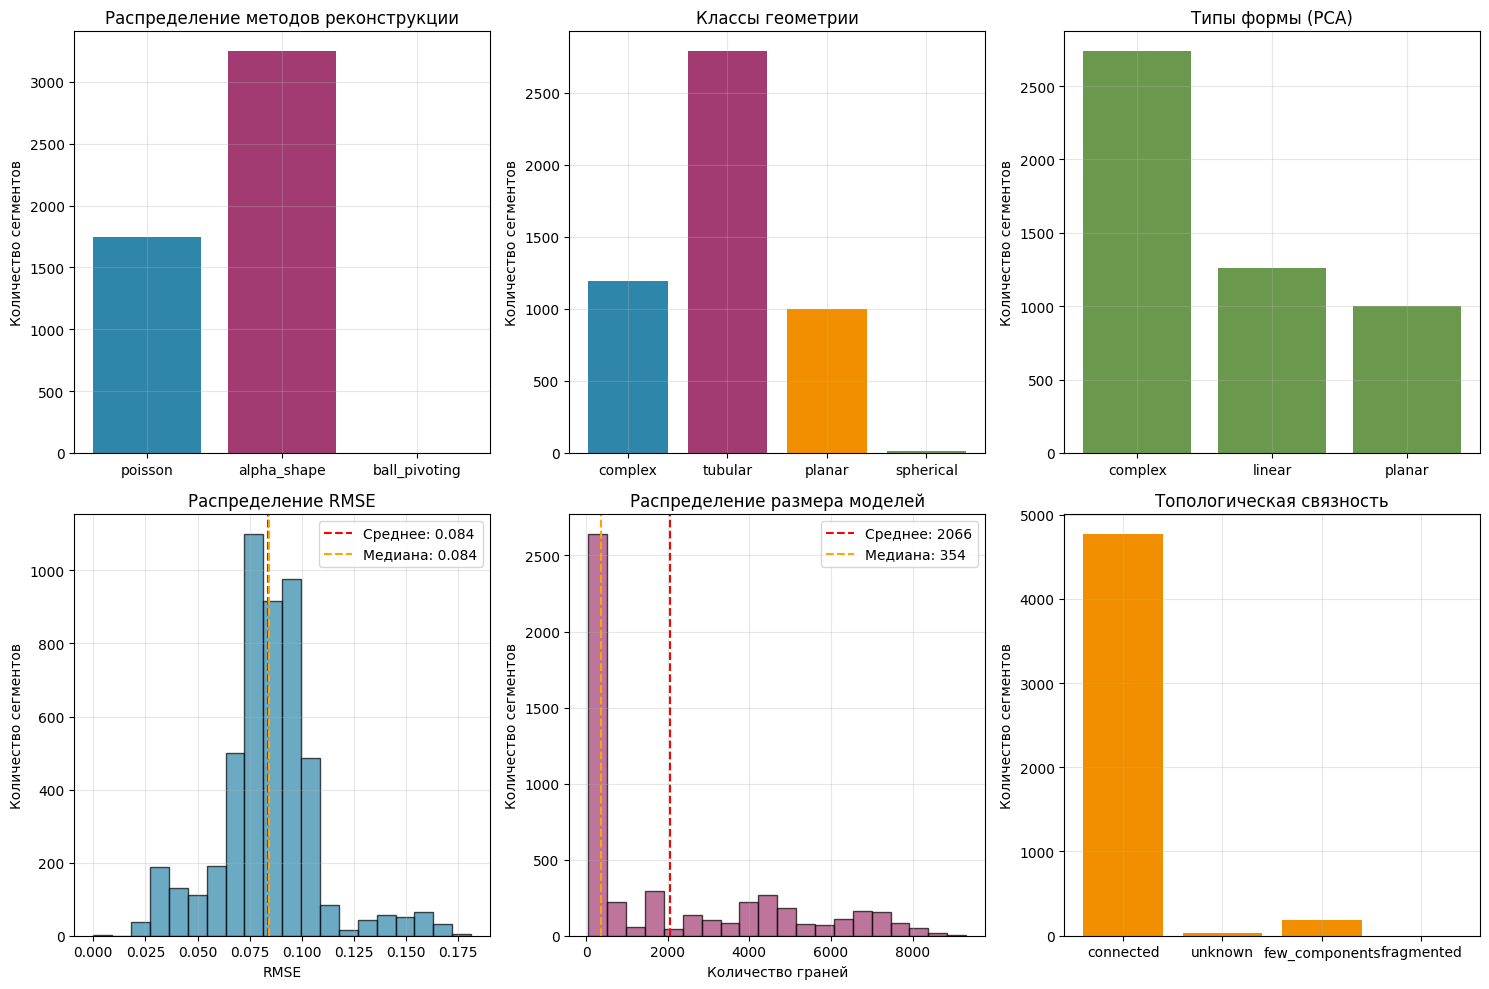

In [16]:
# ============================================
# 7. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================

def plot_global_statistics(global_stats):
    """
    Визуализирует глобальную статистику обработки
    """
    if not global_stats or global_stats['total_meshes'] == 0:
        print("Нет данных для визуализации")
        return

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Распределение методов
    ax1 = axes[0, 0]
    if global_stats['method_counts']:
        methods = list(global_stats['method_counts'].keys())
        counts = list(global_stats['method_counts'].values())
        ax1.bar(methods, counts, color=['#2E86AB', '#A23B72', '#F18F01'])
        ax1.set_title('Распределение методов реконструкции')
        ax1.set_ylabel('Количество сегментов')
        ax1.grid(True, alpha=0.3)

    # 2. Распределение классов
    ax2 = axes[0, 1]
    if global_stats['class_counts']:
        classes = list(global_stats['class_counts'].keys())
        counts = list(global_stats['class_counts'].values())
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#6A994E']
        ax2.bar(classes, counts, color=colors[:len(classes)])
        ax2.set_title('Классы геометрии')
        ax2.set_ylabel('Количество сегментов')
        ax2.grid(True, alpha=0.3)

    # 3. Распределение типов формы
    ax3 = axes[0, 2]
    if global_stats['shape_types']:
        shapes = list(global_stats['shape_types'].keys())
        counts = list(global_stats['shape_types'].values())
        ax3.bar(shapes, counts, color='#6A994E')
        ax3.set_title('Типы формы (PCA)')
        ax3.set_ylabel('Количество сегментов')
        ax3.grid(True, alpha=0.3)

    # 4. Распределение RMSE
    ax4 = axes[1, 0]
    if global_stats['all_rmse']:
        ax4.hist(global_stats['all_rmse'], bins=20, color='#2E86AB', alpha=0.7, edgecolor='black')
        ax4.axvline(np.mean(global_stats['all_rmse']), color='red', linestyle='--', label=f'Среднее: {np.mean(global_stats["all_rmse"]):.3f}')
        ax4.axvline(np.median(global_stats['all_rmse']), color='orange', linestyle='--', label=f'Медиана: {np.median(global_stats["all_rmse"]):.3f}')
        ax4.set_xlabel('RMSE')
        ax4.set_ylabel('Количество сегментов')
        ax4.set_title('Распределение RMSE')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

    # 5. Размеры моделей (грани)
    ax5 = axes[1, 1]
    if global_stats['all_faces']:
        ax5.hist(global_stats['all_faces'], bins=20, color='#A23B72', alpha=0.7, edgecolor='black')
        ax5.axvline(np.mean(global_stats['all_faces']), color='red', linestyle='--', label=f'Среднее: {np.mean(global_stats["all_faces"]):.0f}')
        ax5.axvline(np.median(global_stats['all_faces']), color='orange', linestyle='--', label=f'Медиана: {np.median(global_stats["all_faces"]):.0f}')
        ax5.set_xlabel('Количество граней')
        ax5.set_ylabel('Количество сегментов')
        ax5.set_title('Распределение размера моделей')
        ax5.legend()
        ax5.grid(True, alpha=0.3)

    # 6. Связность
    ax6 = axes[1, 2]
    if global_stats['connectivity']:
        conn = list(global_stats['connectivity'].keys())
        counts = list(global_stats['connectivity'].values())
        ax6.bar(conn, counts, color='#F18F01')
        ax6.set_title('Топологическая связность')
        ax6.set_ylabel('Количество сегментов')
        ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Визуализация результатов
if global_stats:
    plot_global_statistics(global_stats)

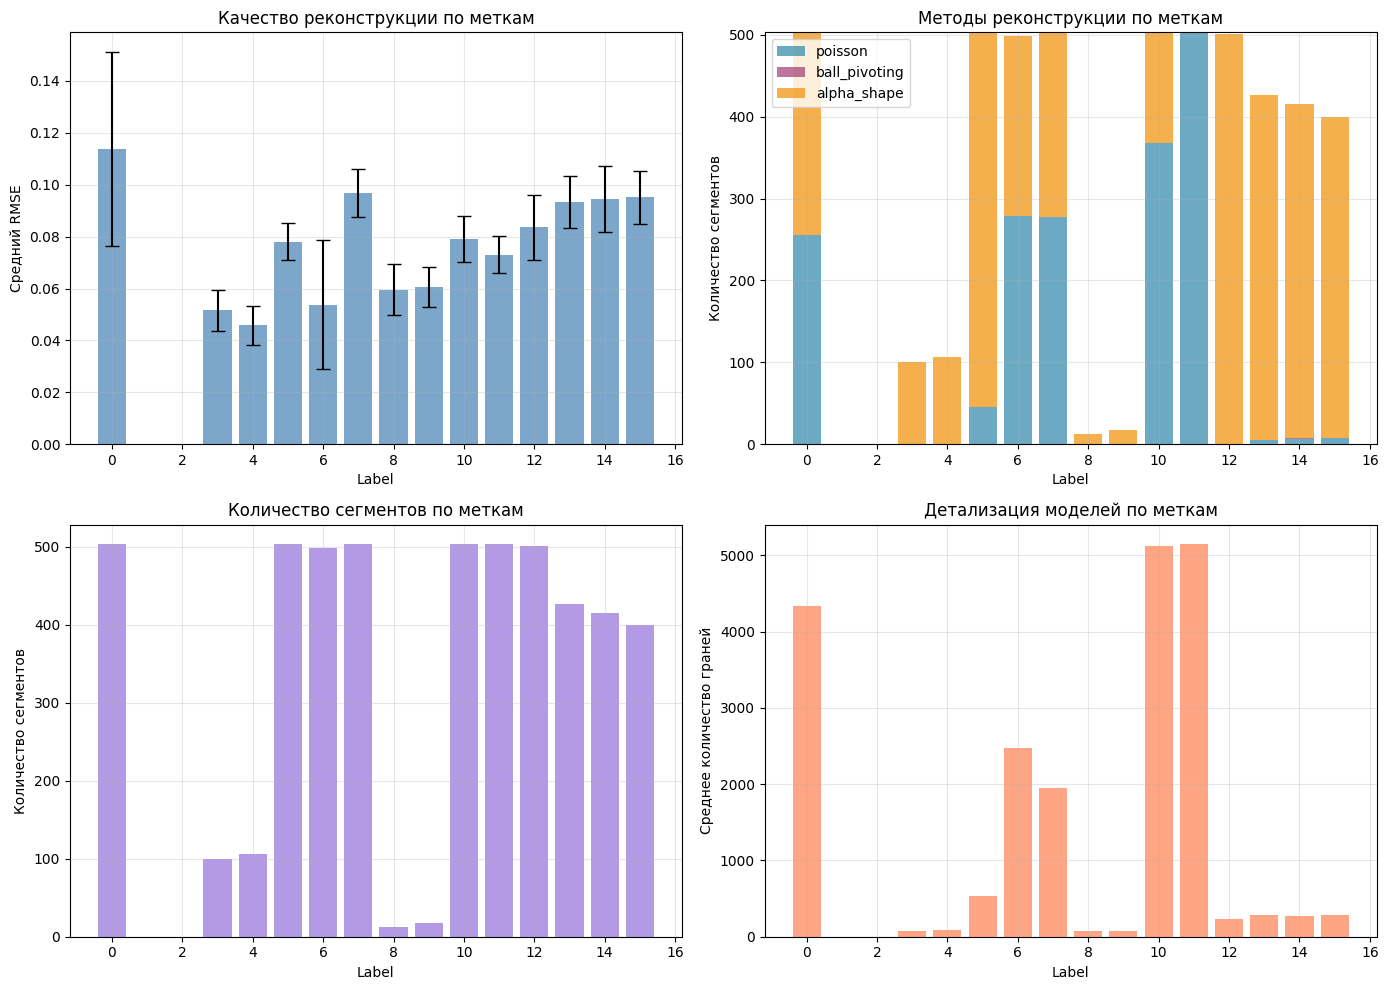


📊 АНАЛИЗ ПО МЕТКАМ:
--------------------------------------------------------------------------------
Label    Count    RMSE mean    RMSE std     Faces mean   Main method    
--------------------------------------------------------------------------------
0        503      0.1139       0.0373       4334         poisson        
3        100      0.0515       0.0080       79           alpha_shape    
4        106      0.0459       0.0075       83           alpha_shape    
5        503      0.0781       0.0072       540          alpha_shape    
6        499      0.0538       0.0249       2472         poisson        
7        503      0.0969       0.0092       1948         poisson        
8        13       0.0596       0.0100       73           alpha_shape    
9        17       0.0607       0.0077       74           alpha_shape    
10       503      0.0789       0.0089       5127         poisson        
11       503      0.0730       0.0072       5142         poisson        
12       501  

In [17]:
# ============================================
# 8. АНАЛИЗ ПО МЕТКАМ (СЕГМЕНТАМ)
# ============================================

def analyze_by_label(all_results):
    """
    Анализирует результаты по меткам сегментов
    """
    label_stats = {}

    for results in all_results:
        if results['status'] != 'success':
            continue

        for label, metrics in results['metrics'].items():
            if label not in label_stats:
                label_stats[label] = {
                    'rmse': [],
                    'faces': [],
                    'vertices': [],
                    'methods': [],
                    'classes': [],
                    'count': 0
                }

            if 'cloud_to_mesh_rmse' in metrics:
                label_stats[label]['rmse'].append(metrics['cloud_to_mesh_rmse'])
            if 'n_faces' in metrics:
                label_stats[label]['faces'].append(metrics['n_faces'])
            if 'n_vertices' in metrics:
                label_stats[label]['vertices'].append(metrics['n_vertices'])
            if 'method_used' in metrics:
                label_stats[label]['methods'].append(metrics['method_used'])

            # Класс из классификации
            if results['classifications'] and label in results['classifications']:
                label_stats[label]['classes'].append(results['classifications'][label]['class'])

            label_stats[label]['count'] += 1

    return label_stats

def plot_label_analysis(label_stats):
    """
    Визуализирует анализ по меткам
    """
    if not label_stats:
        print("Нет данных для визуализации")
        return

    labels = sorted(label_stats.keys())

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Средний RMSE по меткам
    ax1 = axes[0, 0]
    rmse_means = [np.mean(label_stats[l]['rmse']) for l in labels if label_stats[l]['rmse']]
    rmse_stds = [np.std(label_stats[l]['rmse']) for l in labels if label_stats[l]['rmse']]

    if rmse_means:
        ax1.bar(labels, rmse_means, yerr=rmse_stds, capsize=5, color='steelblue', alpha=0.7)
        ax1.set_xlabel('Label')
        ax1.set_ylabel('Средний RMSE')
        ax1.set_title('Качество реконструкции по меткам')
        ax1.grid(True, alpha=0.3)

    # 2. Распределение методов по меткам
    ax2 = axes[0, 1]
    methods_by_label = {}
    for l in labels:
        methods = label_stats[l]['methods']
        if methods:
            unique_methods, counts = np.unique(methods, return_counts=True)
            methods_by_label[l] = dict(zip(unique_methods, counts))

    if methods_by_label:
        bottom = np.zeros(len(labels))
        method_names = ['poisson', 'ball_pivoting', 'alpha_shape']
        colors = ['#2E86AB', '#A23B72', '#F18F01']

        for method, color in zip(method_names, colors):
            values = [methods_by_label.get(l, {}).get(method, 0) for l in labels]
            ax2.bar(labels, values, bottom=bottom, label=method, color=color, alpha=0.7)
            bottom += np.array(values)

        ax2.set_xlabel('Label')
        ax2.set_ylabel('Количество сегментов')
        ax2.set_title('Методы реконструкции по меткам')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # 3. Количество сегментов по меткам
    ax3 = axes[1, 0]
    counts = [label_stats[l]['count'] for l in labels]
    ax3.bar(labels, counts, color='mediumpurple', alpha=0.7)
    ax3.set_xlabel('Label')
    ax3.set_ylabel('Количество сегментов')
    ax3.set_title('Количество сегментов по меткам')
    ax3.grid(True, alpha=0.3)

    # 4. Размер моделей по меткам
    ax4 = axes[1, 1]
    faces_means = [np.mean(label_stats[l]['faces']) for l in labels if label_stats[l]['faces']]
    if faces_means:
        ax4.bar(labels, faces_means, color='coral', alpha=0.7)
        ax4.set_xlabel('Label')
        ax4.set_ylabel('Среднее количество граней')
        ax4.set_title('Детализация моделей по меткам')
        ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Анализ по меткам
if all_results:
    label_stats = analyze_by_label(all_results)
    plot_label_analysis(label_stats)

    # Вывод таблицы
    print("\n📊 АНАЛИЗ ПО МЕТКАМ:")
    print("-" * 80)
    print(f"{'Label':<8} {'Count':<8} {'RMSE mean':<12} {'RMSE std':<12} {'Faces mean':<12} {'Main method':<15}")
    print("-" * 80)

    for label in sorted(label_stats.keys()):
        stats = label_stats[label]
        rmse_mean = np.mean(stats['rmse']) if stats['rmse'] else 0
        rmse_std = np.std(stats['rmse']) if stats['rmse'] else 0
        faces_mean = np.mean(stats['faces']) if stats['faces'] else 0

        # Основной метод
        if stats['methods']:
            method_counts = {}
            for m in stats['methods']:
                method_counts[m] = method_counts.get(m, 0) + 1
            main_method = max(method_counts, key=method_counts.get)
        else:
            main_method = 'N/A'

        print(f"{label:<8} {stats['count']:<8} {rmse_mean:<12.4f} {rmse_std:<12.4f} {faces_mean:<12.0f} {main_method:<15}")